In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime
plt.style.use('seaborn-v0_8-darkgrid')

# Understanding the data

In [3]:
sales_train_eval = pd.read_csv(BASE_DIR / 'data'/'m5-forecasting-accuracy'/'sales_train_evaluation.csv')
sales_train_val =  pd.read_csv(BASE_DIR / 'data'/'m5-forecasting-accuracy'/'sales_train_validation.csv')
calender = pd.read_csv(BASE_DIR/'data'/'m5-forecasting-accuracy'/'calendar.csv')
sell_prices = pd.read_csv(BASE_DIR/'data'/'m5-forecasting-accuracy'/'sell_prices.csv')


In [4]:
sales_train_val.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


In [5]:
sales_train_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 452.9 MB


sales train evaluation contains 28 more days so we should be taking this dataset for further exploration.

In [6]:
np.finfo(np.float16)

finfo(resolution=0.001, min=-6.55040e+04, max=6.55040e+04, dtype=float16)

In [7]:

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Initial memory usage: {start_mem:.2f} MB')

    for col in df.columns:
        # Use Pandas-specific type checkers
        if pd.api.types.is_integer_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)

        elif pd.api.types.is_float_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)

        elif pd.api.types.is_object_dtype(df[col]) or isinstance(df[col].dtype, pd.StringDtype):
            # Only convert to category if it saves space (low cardinality)
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Final memory usage: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    
    return df

def down_data(df):
    """create a dataframe and optimize its memory usage"""
    # df = pd.read_csv(file, parse_dates=True, keep_date_col=True)
    df = reduce_mem_usage(df)
    return df

In [8]:
sales_train_val = down_data(sales_train_val)
calender = down_data(calender)
sales_train_eval = down_data(sales_train_eval)
sell_prices = down_data(sell_prices)


Initial memory usage: 446.40 MB
Final memory usage: 94.03 MB
Decreased by 78.9%
Initial memory usage: 0.21 MB
Final memory usage: 0.06 MB
Decreased by 73.0%
Initial memory usage: 452.91 MB
Final memory usage: 95.17 MB
Decreased by 79.0%
Initial memory usage: 208.77 MB
Final memory usage: 45.69 MB
Decreased by 78.1%


In [9]:
unique_states = sales_train_eval['state_id'].unique()
unique_stores = sales_train_eval['store_id'].unique()
item_unique = sales_train_eval['item_id'].unique()
dept_unique = sales_train_eval['dept_id'].unique()

print("unique states:\t",unique_states)
print("\nunique stores:\t",unique_stores)
print("\ndept unique:\t",dept_unique)
print("\nitemunique:\t",item_unique)
print("\ntotal items: ",len(item_unique)*len(unique_stores)*1941)


unique states:	 ['CA', 'TX', 'WI']
Categories (3, str): ['CA', 'TX', 'WI']

unique stores:	 ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Categories (10, str): ['CA_1', 'CA_2', 'CA_3', 'CA_4', ..., 'TX_3', 'WI_1', 'WI_2', 'WI_3']

dept unique:	 ['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1', 'FOODS_2', 'FOODS_3']
Categories (7, str): ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

itemunique:	 ['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004', 'HOBBIES_1_005', ..., 'FOODS_3_823', 'FOODS_3_824', 'FOODS_3_825', 'FOODS_3_826', 'FOODS_3_827']
Length: 3049
Categories (3049, str): ['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', ..., 'HOUSEHOLD_2_513', 'HOUSEHOLD_2_514', 'HOUSEHOLD_2_515', 'HOUSEHOLD_2_516']

total items:  59181090


*sales_train_val* contains the items, category, category_id, store_id, state_id, and days with item sold in number of units
* There are ~30000 entries, each corresponding to an item avaialable across stores
* 3 states, 10 stores (4 in CA,3 in TX, 3 in WI)
* ~3000 unique items in 3 categories (Hobbies, household, foods)
* total entries in the long format: 59 million

### Checking for NaN or missing values

In [10]:
print("shape:\t",sales_train_eval.shape)
print("\ndate range:\t",calender['date'].min(),' to ',calender['date'].max())
print("\nmissing values",sales_train_eval.isnull().sum().sum())

day_cols = [col for col in sales_train_eval.columns if col.startswith('d_')]
zero_counts = (sales_train_eval[day_cols] == 0).sum(axis=1)
print("\nRows with all zeros:", (zero_counts == len(day_cols)).sum())


shape:	 (30490, 1947)

date range:	 2011-01-29  to  2016-06-19

missing values 0

Rows with all zeros: 0


In [11]:
# Reshape data to long format for easier aggregation
day_cols = [col for col in sales_train_eval.columns if col.startswith('d_')]
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# Melt the data
sales_long = sales_train_eval.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)
sales_long = sales_long.merge(calender, on='d', how='left')
# sales_long.head(10)
sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


### Item sale patterns

In [ ]:
hobbies_1_ca_1  = sales_long[(sales_long['id']=='HOBBIES_1_001_CA_1_validation')]
food_1_ca_1 = sales_long[(sales_long['id'])=='FOODS_1_001_CA_1_validation']
household_1_ca_1 = sales_long[(sales_long['id'])=='HOUSEHOLD_1_001_CA_1_validation']


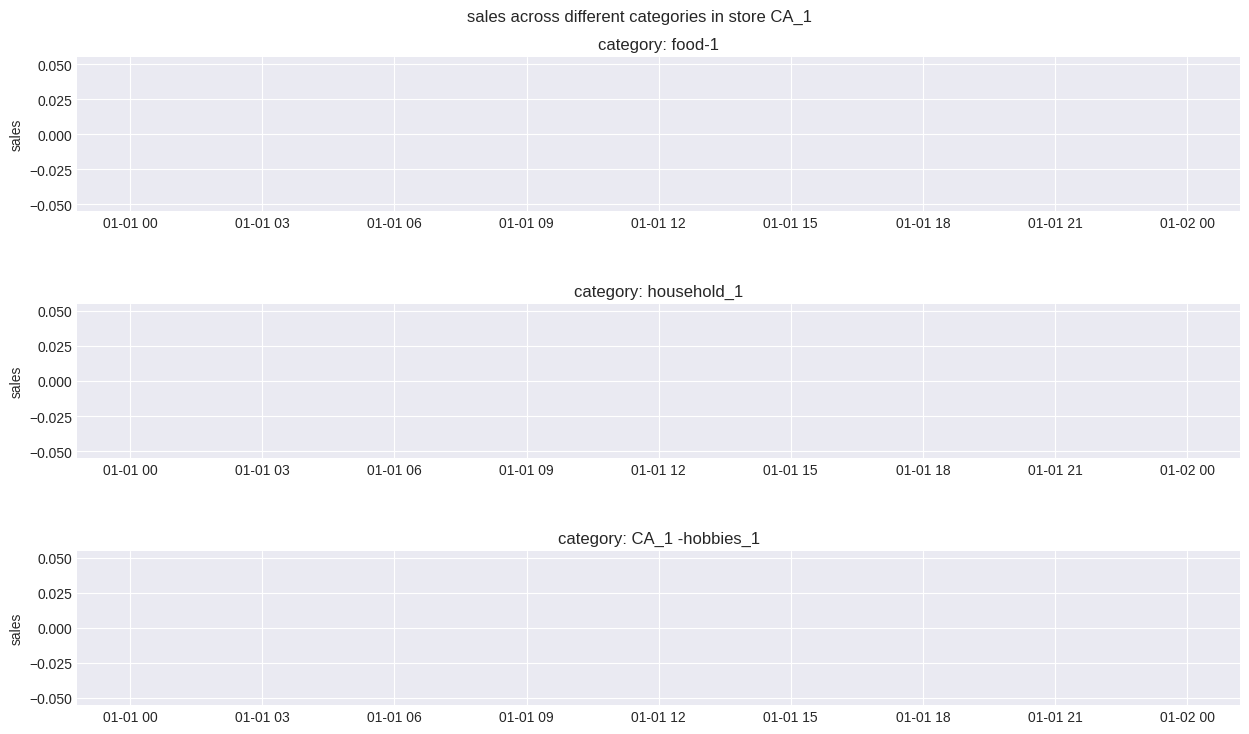

In [ ]:
fig,ax = plt.subplots(nrows=3,ncols=1,figsize=(15,8))
fig.suptitle("sales across different categories in store CA_1")
ax[0].plot(food_1_ca_1['date'], food_1_ca_1['sales'])
ax[0].set_title('category: food-1')
ax[0].set_ylabel('sales')

ax[1].plot(household_1_ca_1['date'],household_1_ca_1['sales'])
ax[1].set_title('category: household_1')
ax[1].set_ylabel("sales")

ax[2].plot(hobbies_1_ca_1['date'], hobbies_1_ca_1['sales'])
ax[2].set_title('category: CA_1 -hobbies_1')
ax[2].set_ylabel("sales")


# ax[0].set_ylabel('Sales')
plt.subplots_adjust(hspace=0.6, wspace=0.3, top=0.92)



Looking at the plots,we can see that, the data is intermittent (we have to classify properly using $CV^2$ and ADI (Average demand intervel)),
before focusing on this, we go top-down approach to identify patterns and trends at global level

## Aggregate
Aggregating the data at global level to figure out the patterns (seasonality, trend)

### Different levels:

Levels : State, Stores, Categories (Foods,Household,Hobbies), Departments (Foods_1,2,3,Household_1,2,Hobbies_1,2),items (Foods_1_1,2_2,etc.)

1. State level:  state vs sales(total)
2. Store level: Stores vs sales
3. State - category level: state,category vs sales 
4. Store - category level: store,category vs sales
5. Store - dept level :  store, dept vs sales


## 1. State Level

In [ ]:
state_lvl = sales_long.groupby(['state_id' , 'date'])['sales'].sum().reset_index()
state_lvl

,state_id,date,sales
0,CA,2011-01-29,14195
1,CA,2011-01-30,13805
2,CA,2011-01-31,10108
3,CA,2011-02-01,11047
4,CA,2011-02-02,9925
...,...,...,...
5818,WI,2016-05-18,11043
5819,WI,2016-05-19,11504
5820,WI,2016-05-20,12819
5821,WI,2016-05-21,14734


In [ ]:
# import gc
# gc.collect(sales_long)

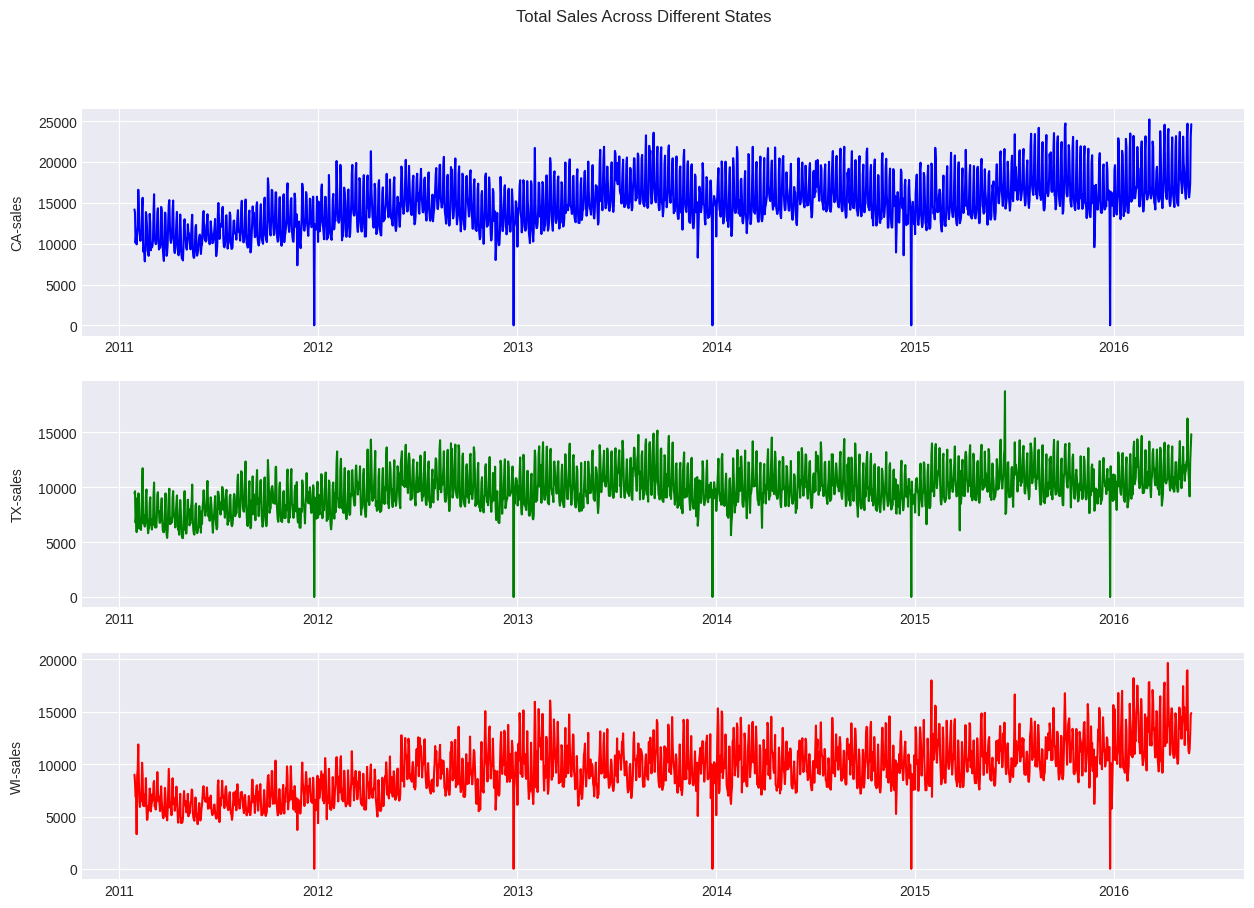

In [ ]:
figs,axs = plt.subplots(nrows=3,ncols=1,figsize=(15,10))
color = ['blue','green','red']
figs.suptitle("Total Sales Across Different States")
for idx,state in enumerate(state_lvl['state_id'].unique()):
    mask = state_lvl['state_id']==state

    axs[idx].plot(state_lvl[mask]['date'],state_lvl[mask]['sales'],c=color[idx])
    axs[idx].set_ylabel(f'{state}-sales',labelpad=10)


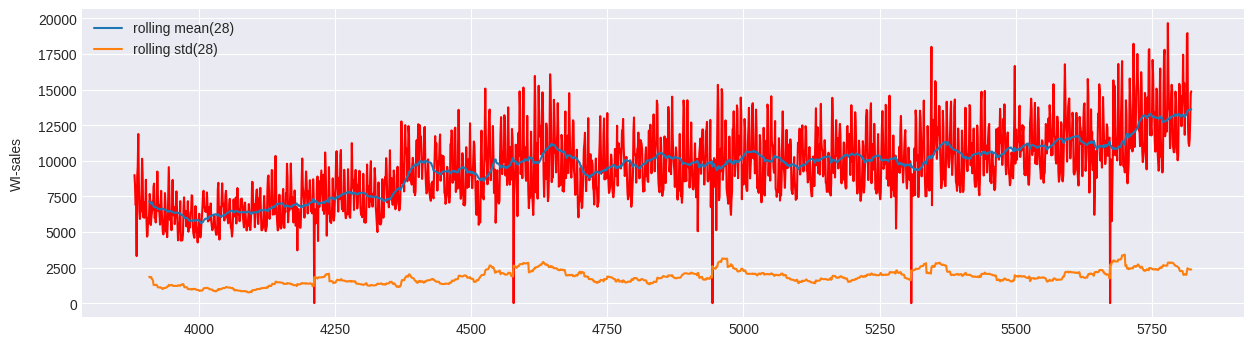

In [ ]:
fig = plt.figure(figsize=(15,4))
mask = state_lvl['state_id']==state
plt.plot(state_lvl[mask]['sales'],c=color[idx])
plt.ylabel(f'{state}-sales',labelpad=10)
rolling_mean  = state_lvl[mask]['sales'].rolling(28).mean()
rolling_std = state_lvl[mask]['sales'].rolling(28).std()

plt.plot(rolling_mean,label='rolling mean(28)')
plt.plot(rolling_std,label='rolling std(28)')
plt.legend()

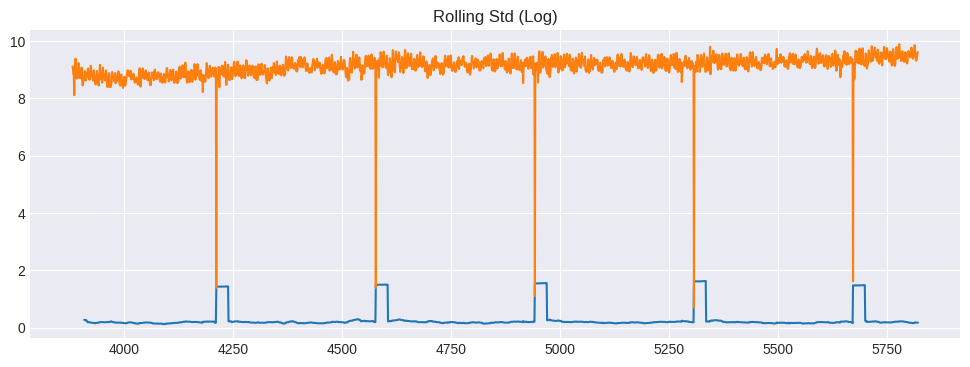

In [ ]:
log_series = np.log1p(state_lvl[mask]['sales'])

rolling_std_log = log_series.rolling(28).std()

plt.figure(figsize=(12,4))
plt.plot(rolling_std_log)
plt.plot(log_series)
plt.title("Rolling Std (Log)")
plt.show()

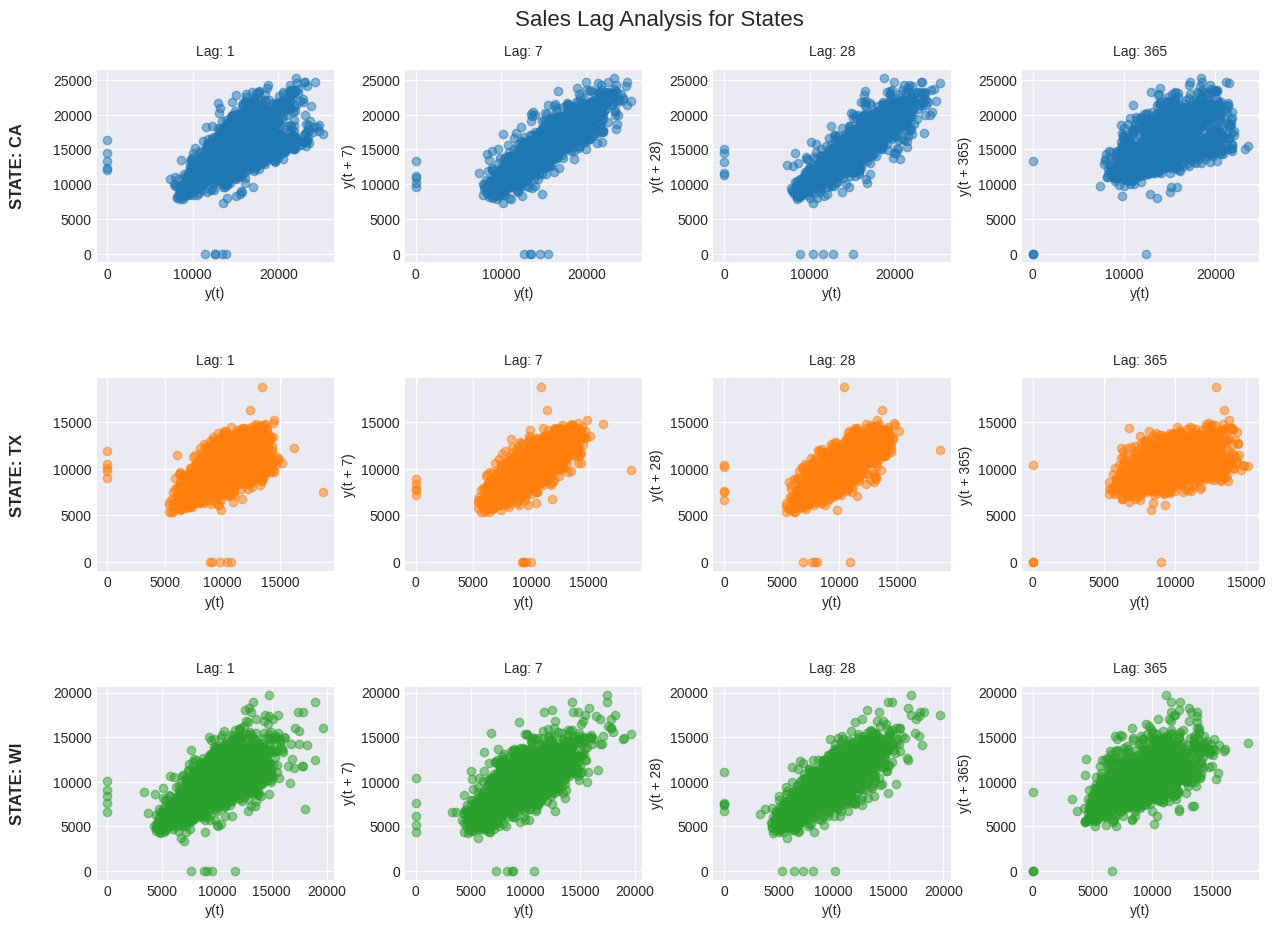

In [ ]:
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import  plot_acf


fig_2,ax_2 = plt.subplots(nrows=3,ncols=4,figsize=(15,10))
fig_2.suptitle(f"Sales Lag Analysis for States", fontsize=16, y=0.98)
lags = [1,7,28,365]
row_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green (Standard Matplotlib Tab10)
for idx,state in enumerate(state_lvl['state_id'].unique()):
    for jdx,lag in enumerate(lags):
        mask = state_lvl['state_id']==state
        ax_2[idx, 0].set_ylabel(f"STATE: {state}", fontweight='bold', fontsize=12, labelpad=20)
        lag_plot(state_lvl[mask]['sales'],lag=lag,ax=ax_2[idx,jdx],c=row_colors[idx % len(row_colors)], alpha=0.5)
        ax_2[idx, jdx].set_title(f'Lag: {lag}', fontsize=10, pad=10)
        # break
plt.subplots_adjust(hspace=0.6, wspace=0.3, top=0.92)


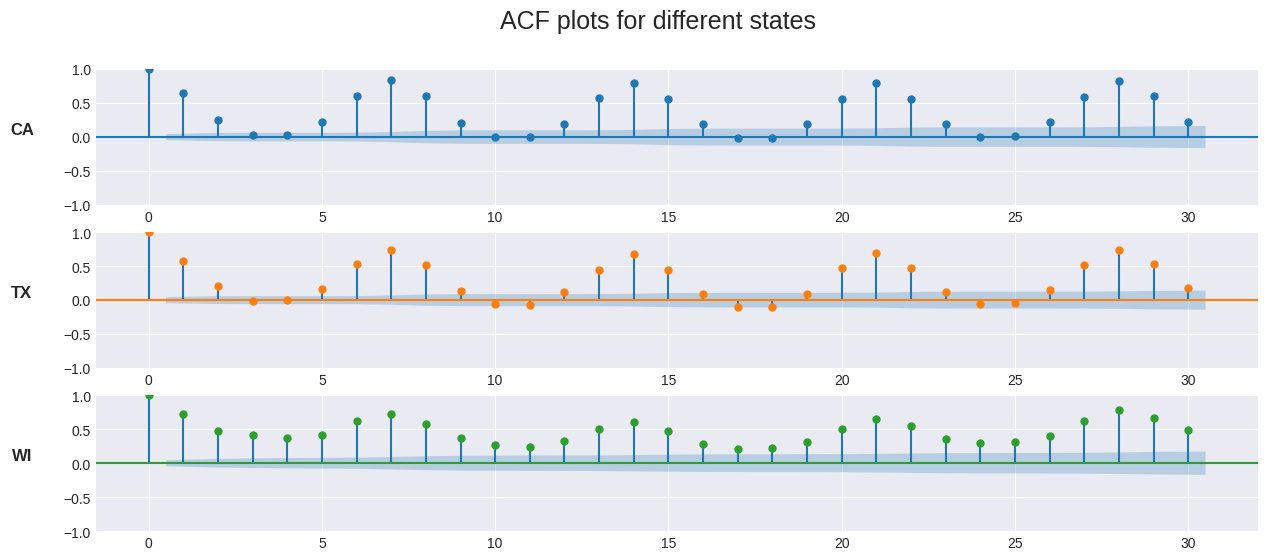

In [ ]:
# ploting the ACF for different state 
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,6))
row_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
fig.suptitle(f"ACF plots for different states",fontsize=18)
for idx, state in enumerate(state_lvl['state_id'].unique()):
    # Filter data for the specific state and category
    mask = state_lvl['state_id']==state
    sales_data = state_lvl[mask]['sales']
    # 2. Plot ACF onto the specific row
    # lags=30 shows the correlation for the last month
    plot_acf(sales_data, lags=30, ax=ax[idx], color=row_colors[idx], title="")
    # 3. Custom Annotation & Spacing
    ax[idx].set_ylabel(f"{state}", fontweight='bold', fontsize=12, rotation=0, labelpad=30)
    # ax[idx].set_title(f"Autocorrelation: {state} ({cat_id})", loc='right', fontsize=10)


The lag plots and ACF plots clearly reveal a weekly seasonality

### Decomposition:
To see the underlying patterns (seasonality, trend and  resid), we decompose the data

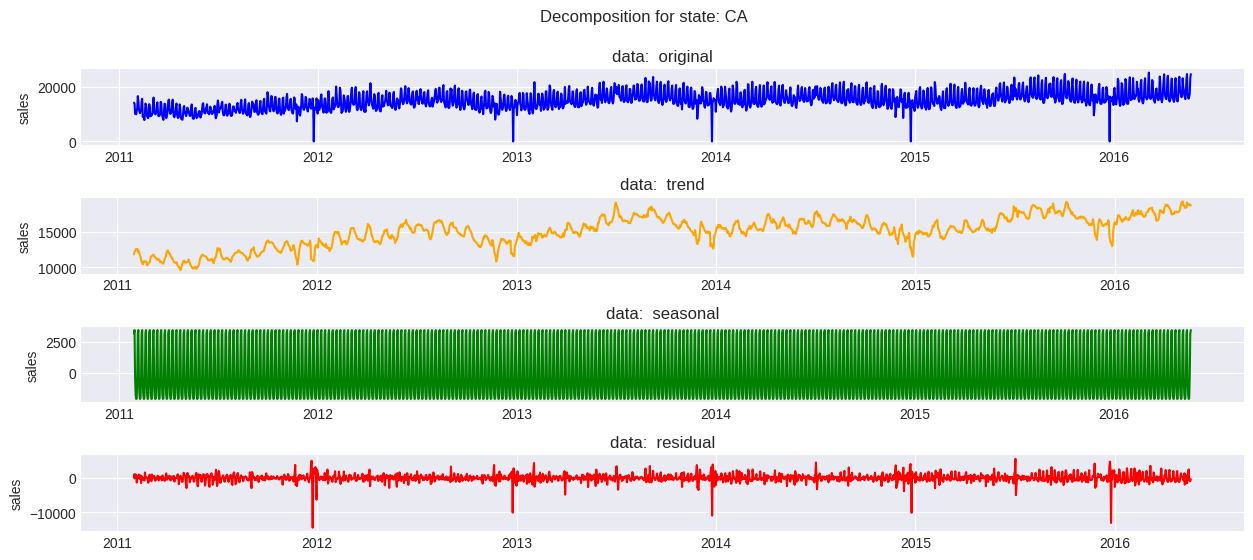

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# only do it for one state and one category (FOODS)
state= 'CA'

mask = (state_lvl['state_id'] == state) 

sales_data_state = state_lvl[mask]['sales']
dates = state_lvl[mask]['date']
decomp_CA = seasonal_decompose(sales_data_state,model='additive',period=7) #period is 7 from our acf plot,

fig_3,ax_3 = plt.subplots(nrows=4,ncols=1,figsize=(15,6))

decompos = [sales_data_state,decomp_CA.trend,decomp_CA.seasonal,decomp_CA.resid]
titles = ['original','trend','seasonal','residual']
colors  = ['blue','orange','green','red']
fig_3.suptitle(f'Decomposition for state: {state}')
for i,data in enumerate(decompos):
    ax_3[i].plot(dates,data,c=colors[i])
    ax_3[i].set_title(f'data:  {titles[i]}')
    ax_3[i].set_ylabel('sales')

plt.subplots_adjust(hspace=0.7)

Lets use a baseline model to forecast for global level (although in reality, we do a bottom-up modelling- model the lowest level and aggregate)

### 1. Baseline models

In [ ]:
calender['date'] = pd.to_datetime(calender['date'])
state_lvl_merged  = state_lvl.merge(calender,on='date',how='left')
# state_lvl_merged|

In [ ]:
state_lvl_merged

,state_id,date,sales,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,CA,2011-01-29,14195,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,CA,2011-01-30,13805,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,CA,2011-01-31,10108,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,CA,2011-02-01,11047,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,CA,2011-02-02,9925,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818,WI,2016-05-18,11043,11616,Wednesday,5,5,2016,d_1937,NaN,NaN,NaN,NaN,0,0,0
5819,WI,2016-05-19,11504,11616,Thursday,6,5,2016,d_1938,NaN,NaN,NaN,NaN,0,0,0
5820,WI,2016-05-20,12819,11616,Friday,7,5,2016,d_1939,NaN,NaN,NaN,NaN,0,0,0
5821,WI,2016-05-21,14734,11617,Saturday,1,5,2016,d_1940,NaN,NaN,NaN,NaN,0,0,0


Figuring out correlation on exogeneous variables,
1. snap_CA,snap_TX,snap_WI
2. sell price

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# split the data to train and test split, 
# for CA
state = 'CA'
mask = state_lvl_merged['state_id']==state
ca_sales = state_lvl_merged[mask].sort_values('date')
ca_train,ca_test = ca_sales.iloc[:-28],ca_sales.iloc[-28:]
# ca_train.iloc[:,-3]
# ca_test.iloc[:,-3]

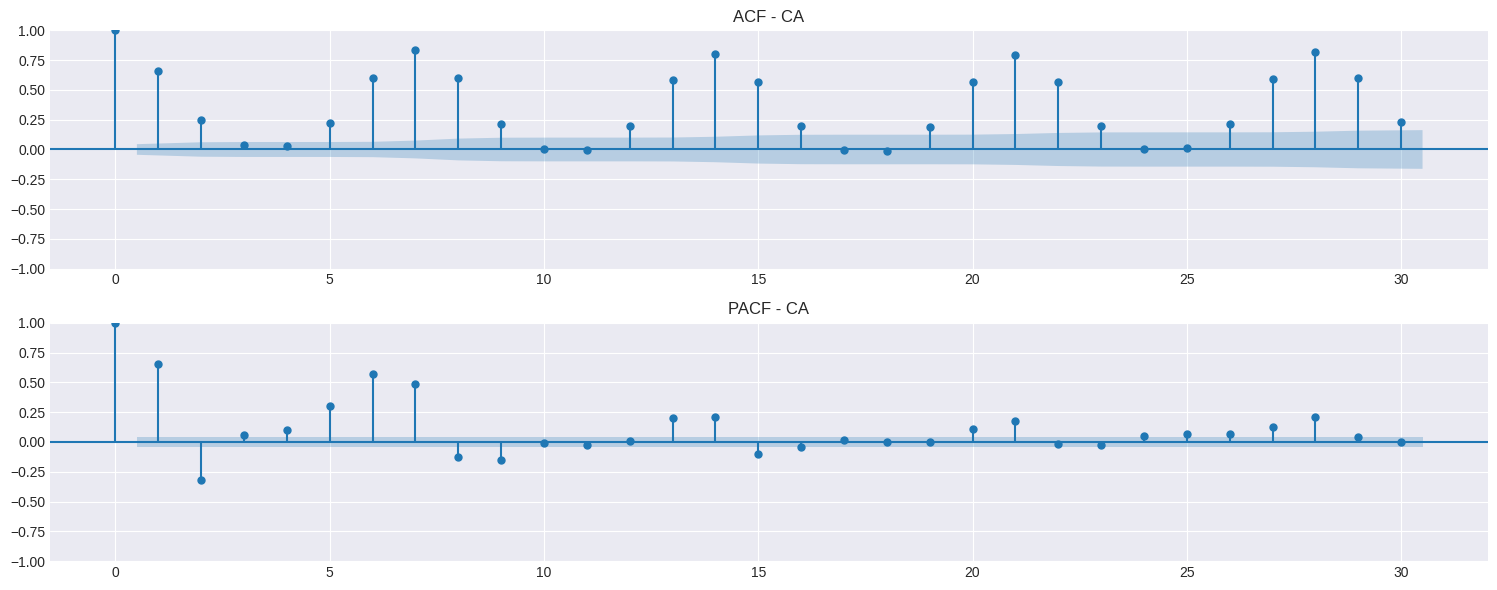

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15, 6))
plot_acf(ca_sales['sales'], lags=30, ax=axes[0], title='ACF - CA')
plot_pacf(ca_sales['sales'], lags=30, ax=axes[1], title='PACF - CA')
plt.tight_layout()

ADF p-value (raw): 0.5018
ADF p-value (diff1): 0.0000
ADF p-value (diff1 + seasonal diff): 0.0000


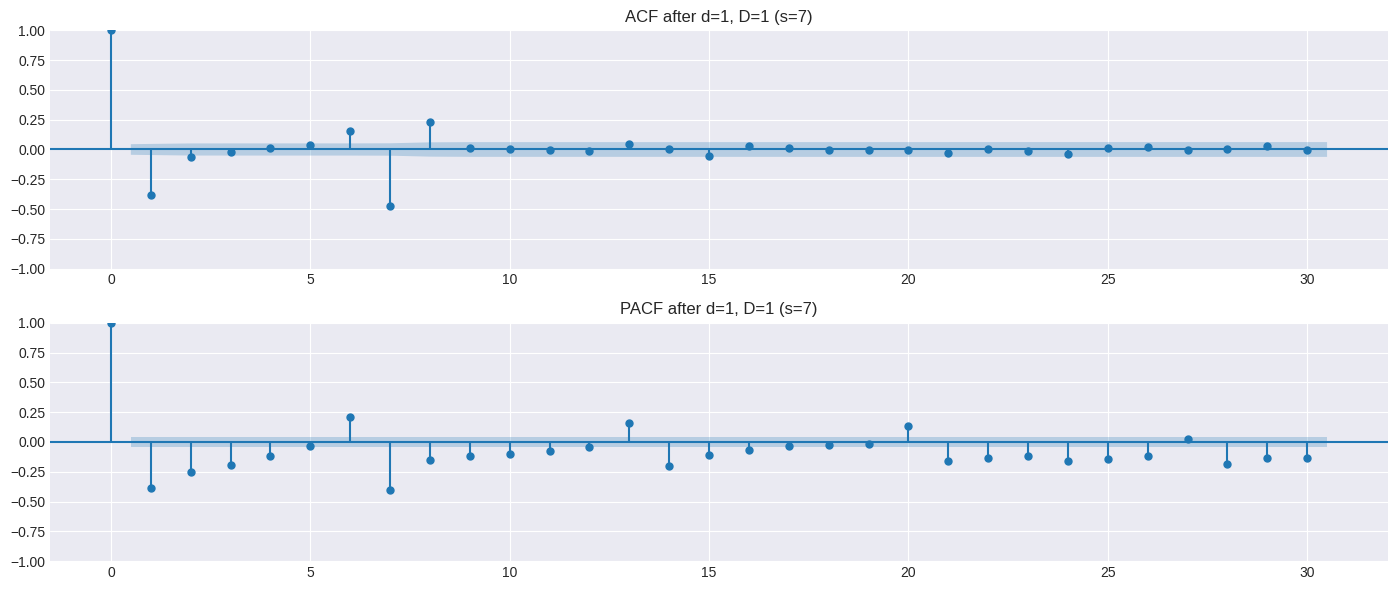

In [ ]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt


# 1. ADF test on raw series
result = adfuller(sales_data_state)
print(f'ADF p-value (raw): {result[1]:.4f}')  # expect > 0.05 → non-stationary

# 2. First difference (removes trend)
sales_diff1 = sales_data_state.diff().dropna()
result2 = adfuller(sales_diff1)
print(f'ADF p-value (diff1): {result2[1]:.4f}')  # might still be > 0.05

# 3. Seasonal difference on top (removes weekly pattern)
sales_diff1_7 = sales_diff1.diff(7).dropna()
result3 = adfuller(sales_diff1_7)
print(f'ADF p-value (diff1 + seasonal diff): {result3[1]:.4f}')  # expect < 0.05

# 4. NOW plot ACF and PACF on the fully differenced series
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(sales_diff1_7, lags=30, ax=axes[0], title='ACF after d=1, D=1 (s=7)')
plot_pacf(sales_diff1_7, lags=30, ax=axes[1], title='PACF after d=1, D=1 (s=7)')
plt.tight_layout()
plt.show()

In [ ]:
#The five baselines 
#------------------------
# Naive, repeat the last value of training
f_naive = np.full(28,ca_train.iloc[-1,2])

# Seasonal Naive, repeat the last 28 days
f_snaive = ca_train.iloc[-28:,2]

# Rolling average (last 30 days mean)
f_rolling = np.full(28,ca_train.iloc[-30:,2].mean())

# ARIMA and SARIMA
model_arima = SARIMAX(ca_train.iloc[:,2], order=(1,1,1))# order= p,d,q
res_arima = model_arima.fit(disp=False)
f_arima = res_arima.forecast(steps=28)

model_sarima = SARIMAX(ca_train.iloc[:,2], order=(1,1,1), seasonal_order=(1,1,1,7))# order P,D,Q ,S=7
res_sarima = model_sarima.fit(disp=False)
f_sarima = res_sarima.forecast(steps=28)

model_sarima_exog = SARIMAX(ca_train.iloc[:,2],exog=ca_train.iloc[:,-3],order=(1,1,1),seasonal_order=(1,1,1,7))
res_sarima_exog = model_sarima_exog.fit(disp=False)
f_sarima_exog = res_sarima_exog.forecast(steps=28,exog=ca_test.iloc[:,-3])

# exponential smoothing
#1.simple exponential smoothing

model_ses = SimpleExpSmoothing(ca_train.iloc[:,2]).fit(smoothing_level=0.3,optimized=False)
f_ses =  model_ses.forecast(28)

#2. Holt expo smoothing, # trend only
model_holt = ExponentialSmoothing(ca_train.iloc[:,2],trend='add',seasonal='add',seasonal_periods=7).fit(optimized=True)
f_holt = model_holt.forecast(28)

# 3. Compare Results
results = {
    "Naive": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_naive)),
    "S-Naive": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_snaive)),
    "Rolling": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_rolling)),
    "ARIMA": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_arima)),
    "SARIMA": np.sqrt(mean_squared_error(ca_test.iloc[:,2], f_sarima)),
    "SARIMA_exog":np.sqrt(mean_squared_error(ca_test.iloc[:,2],f_sarima_exog)),
    "Exponential Smooth":np.sqrt(mean_squared_error(ca_test.iloc[:,2],f_ses)),
    "Holt Expo Smooth": np.sqrt(mean_squared_error(ca_test.iloc[:,2],f_holt))

}
# print(results)
results

{'Naive': np.float64(5531.671021103323),
 'S-Naive': np.float64(1480.298920102674),
 'Rolling': np.float64(3126.1381346359917),
 'ARIMA': np.float64(3338.548216538764),
 'SARIMA': np.float64(1184.6498809612924),
 'SARIMA_exog': np.float64(1123.8672657288062),
 'Exponential Smooth': np.float64(3271.098504170033),
 'Holt Expo Smooth': np.float64(1211.3702340622062)}

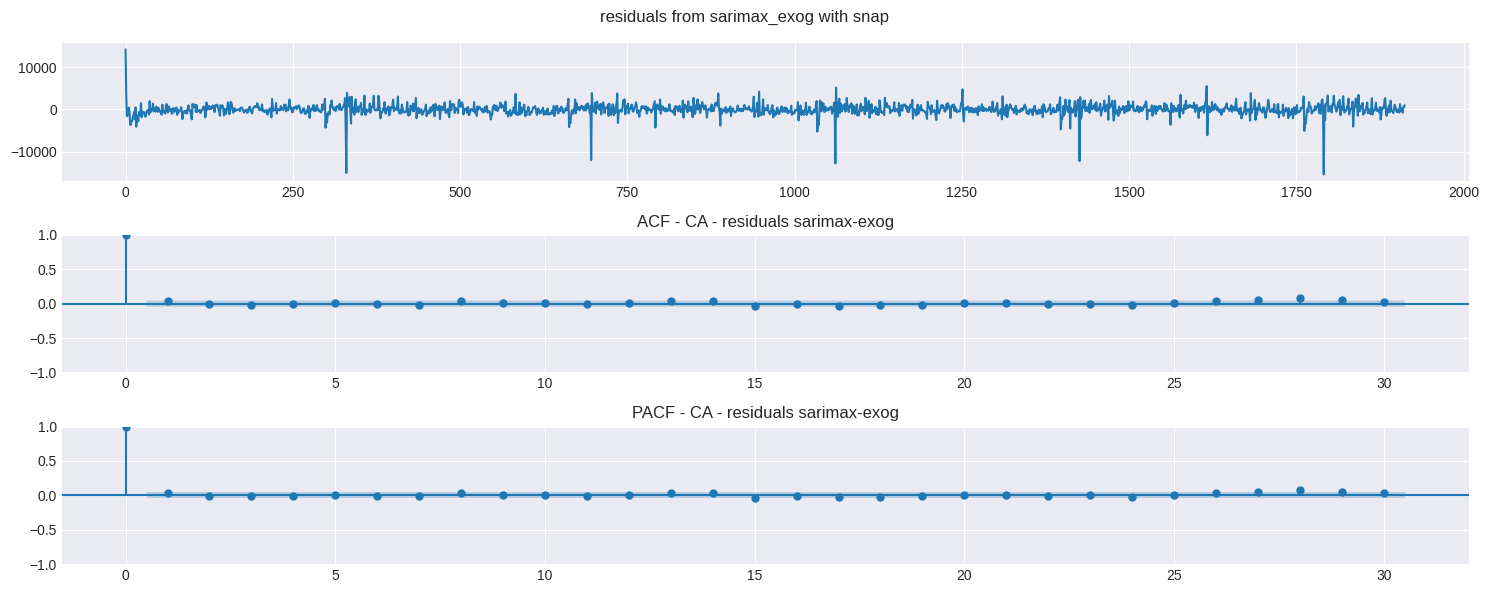

In [ ]:
# fig = plt.figure(figsize=(15,4))
fig, axes = plt.subplots(3, 1, figsize=(15, 6))
residuals = res_sarima_exog.resid
axes[0].plot(residuals)
fig.suptitle("residuals from sarimax_exog with snap")

# to check whether residual is white noise, performing acf

plot_acf(residuals, lags=30, ax=axes[1], title='ACF - CA - residuals sarimax-exog')
plot_pacf(residuals, lags=30, ax=axes[2], title='PACF - CA - residuals sarimax-exog')
plt.tight_layout()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(residuals, lags=[10,20,30], return_df=True)
print(lb)

      lb_stat  lb_pvalue
10   6.166206   0.801111
20  16.693452   0.672780
30  43.462180   0.053315


In [ ]:
print(f"\nHolt-Winters parameters found:")
print(f"α (level):    {model_holt.params['smoothing_level']:.3f}")
print(f"β (trend):    {model_holt.params['smoothing_trend']:.3f}")
print(f"γ (seasonal): {model_holt.params['smoothing_seasonal']:.3f}")


Holt-Winters parameters found:
α (level):    0.217
β (trend):    0.000
γ (seasonal): 0.041


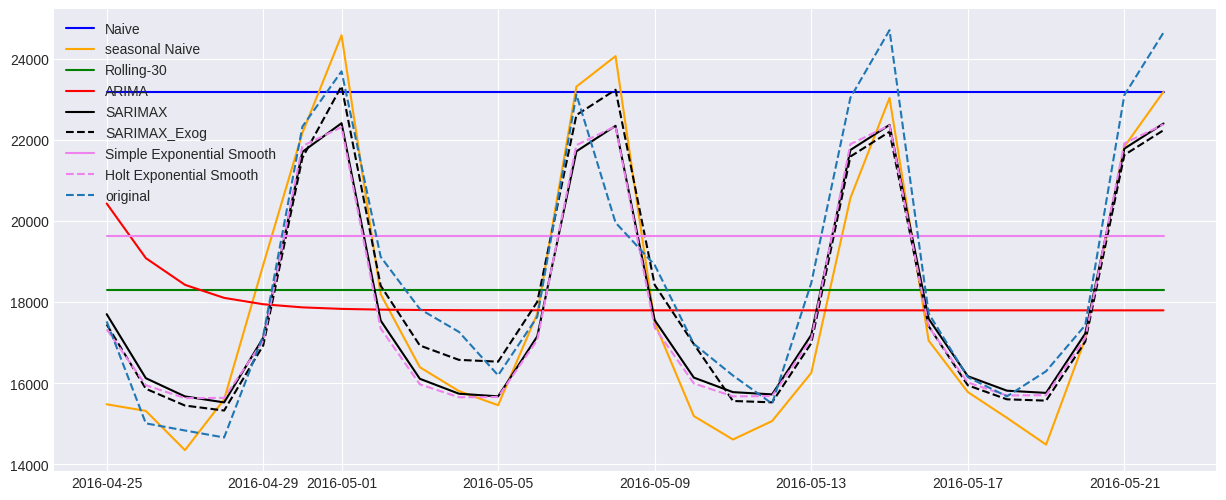

In [ ]:
#plotting the predicted vs real\
plt.figure(figsize=(15,6))
test_dates = ca_test['date']
plt.plot(test_dates,f_naive,'blue',label='Naive')
plt.plot(test_dates,f_snaive,'orange',label='seasonal Naive')
plt.plot(test_dates,f_rolling,'green',label='Rolling-30')
plt.plot(test_dates,f_arima,'red',label='ARIMA')
plt.plot(test_dates,f_sarima,'black',label='SARIMAX')
plt.plot(test_dates,f_sarima_exog,'black',linestyle='--',label='SARIMAX_Exog')
plt.plot(test_dates,f_ses,'violet',label='Simple Exponential Smooth')
plt.plot(test_dates,f_holt,'violet',linestyle='--',label='Holt Exponential Smooth')

plt.plot(test_dates,ca_test['sales'],linestyle='--',label='original')
# plt.plot(test_dates,ca_test['sales'],label='seasonal Naive')
# plt.plot(test_dates,f_rolling,'green',label='Rolling-30')
# plt.plot(test_dates,f_snaive,'red',label='ARIMA')
# plt.plot(test_dates,f_snaive,'black',label='SARIMAX')
plt.legend()


### Time Series Models
From the above plot, three models perform neatly:
1. Seasonal Naive, without any modelling, it give us 1305 in mse
2. Sarima (sarima exog): best with snap variable , least mse ~ 800
3. Exponential Smoothing (Holts): captures seasonality and trend (no possiblity for exog variable)


### Regression Models:
making features for regression models


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

def make_features(df):
    df = df.copy()
    
    # Calendar features — capture weekly seasonality
    df['day_of_week']   = df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
    df['day_of_month']  = df['date'].dt.day
    df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)
    df['month']         = df['date'].dt.month
    
    # Lag features — give the model memory of past sales
    df['lag_7']         = df['sales'].shift(7)    # same day last week
    df['lag_14']        = df['sales'].shift(14)   # same day 2 weeks ago
    df['lag_28']        = df['sales'].shift(28)   # same day 4 weeks ago
    
    # Rolling features — local trend signal
    df['rolling_mean_7']  = df['sales'].shift(1).rolling(7).mean()
    df['rolling_mean_28'] = df['sales'].shift(1).rolling(28).mean()
    df['rolling_std_7']   = df['sales'].shift(1).rolling(7).std()
    
    return df

ca_df = ca_sales[['date','sales','snap_CA']]
ca_df = make_features(ca_df)
ca_df = ca_df.dropna()

ca_df

,date,sales,snap_CA,day_of_week,day_of_month,week_of_year,month,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7
28,2011-02-26,13652,0,5,26,8,2,13870.0,14610.0,14195.0,10823.428571,11459.642857,2248.513498
29,2011-02-27,12491,0,6,27,8,2,13465.0,15630.0,13805.0,10792.285714,11440.250000,2200.276779
30,2011-02-28,9196,0,0,28,9,2,11997.0,9044.0,10108.0,10653.142857,11393.321429,2027.067293
31,2011-03-01,9782,1,1,1,9,3,9130.0,9496.0,11047.0,10253.000000,11360.750000,1993.762106
32,2011-03-02,9537,1,2,2,9,3,8941.0,8844.0,9925.0,10346.142857,11315.571429,1947.241932
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,2016-05-18,15678,0,2,18,20,5,16191.0,17266.0,15148.0,18824.571429,18420.357143,3624.229245
1937,2016-05-19,16297,0,3,19,20,5,15498.0,16197.0,14488.0,18751.285714,18439.285714,3690.931306
1938,2016-05-20,17430,0,4,20,20,5,18471.0,17638.0,17095.0,18865.428571,18503.892857,3584.371021
1939,2016-05-21,23103,0,5,21,20,5,23037.0,23119.0,21834.0,18716.714286,18515.857143,3624.830190


Linear Regression RMSE: 1271.55

Feature weights:
            feature      weight
10          snap_CA  637.841548
0       day_of_week  124.896198
3             month   13.598581
4             lag_7    0.352429
6            lag_28    0.261668
5            lag_14    0.240103
8   rolling_mean_28    0.220888
9     rolling_std_7   -0.043708
7    rolling_mean_7   -0.082593
2      week_of_year  -17.685309
1      day_of_month  -44.959226

Ridge Regression RMSE: 1250.79


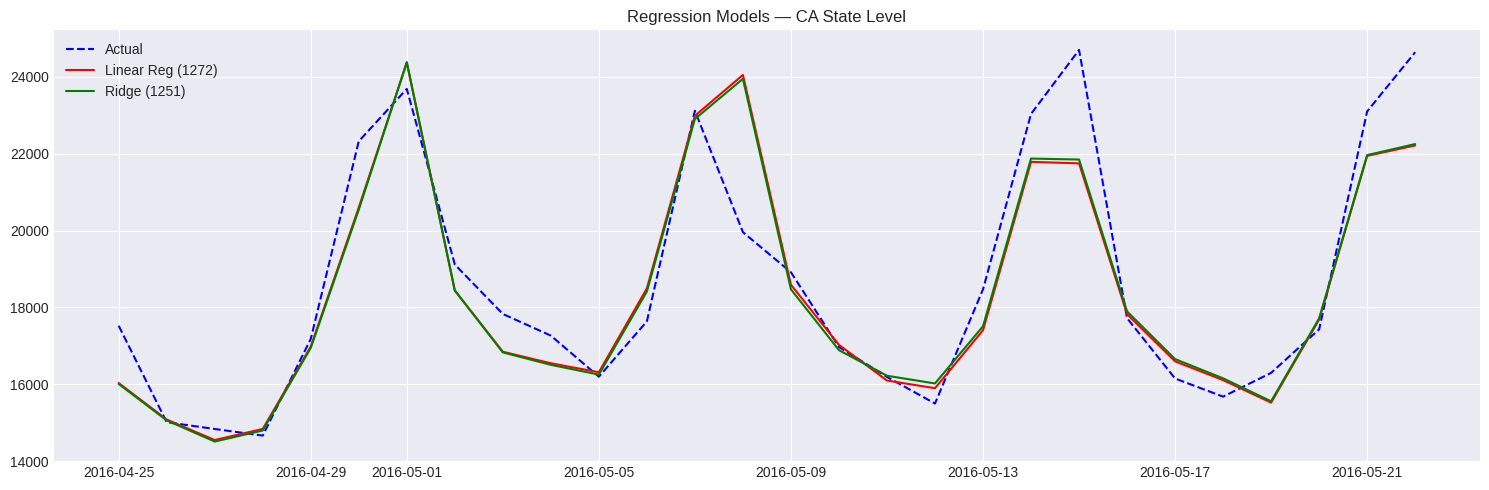

SARIMAX             : 808
Holt-Winters        : 1073
SARIMA              : 1099
Ridge               : 1251
Linear Reg          : 1272
S-Naive             : 1305
Rolling             : 3299
ARIMA               : 3445
Naive               : 4659


In [ ]:
cutoff = ca_df['date'].max() - pd.Timedelta(days=28)
train  = ca_df[ca_df['date'] <= cutoff]
test   = ca_df[ca_df['date'] >  cutoff]

feature_cols = [
    'day_of_week', 'day_of_month', 'week_of_year', 'month',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    'snap_CA'
]



X_train = train[feature_cols]
y_train = train['sales']
X_test  = test[feature_cols]
y_test  = test['sales']

lr = LinearRegression()
lr.fit(X_train, y_train)
f_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, f_lr))
print(f"Linear Regression RMSE: {rmse_lr:.2f}")

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'weight':  lr.coef_
}).sort_values('weight', ascending=False)
print("\nFeature weights:")
print(coef_df)

ridge = Ridge(alpha=100)   # alpha controls penalty strength
ridge.fit(X_train, y_train)
f_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, f_ridge))
print(f"\nRidge Regression RMSE: {rmse_ridge:.2f}")

plt.figure(figsize=(15, 5))
plt.plot(test['date'], y_test,   'b--', label='Actual')
plt.plot(test['date'], f_lr,     'red',    label=f'Linear Reg ({rmse_lr:.0f})')
plt.plot(test['date'], f_ridge,  'green',  label=f'Ridge ({rmse_ridge:.0f})')
plt.legend()
plt.title('Regression Models — CA State Level')
plt.tight_layout()
plt.show()

results = {
    'Naive':          4659,
    'S-Naive':        1305,
    'Rolling':        3299,
    'ARIMA':          3445,
    'SARIMA':         1099,
    'SARIMAX':         808,
    'Holt-Winters':   1073,
    'Linear Reg':     rmse_lr,
    'Ridge':          rmse_ridge,
}
for model, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model:20s}: {rmse:.0f}")


## For the other states:

In [ ]:
## Texas
tx_state = 'TX'
tx_mask = state_lvl_merged['state_id']==tx_state
tx_sales = state_lvl_merged[tx_mask].sort_values('date')
tx_train,tx_test = tx_sales.iloc[:-28],tx_sales.iloc[-28:]

## Wisconsin
wi_state = 'WI'
wi_mask = state_lvl_merged['state_id']==wi_state
wi_sales = state_lvl_merged[wi_mask].sort_values('date')
wi_train,wi_test = wi_sales.iloc[:-28],wi_sales.iloc[-28:]

In [ ]:
# fitting the sarimax with snap  

sarimax_snap_tx = SARIMAX(tx_train.iloc[:,2],exog=tx_train.iloc[:,-2],order=(1,1,1),seasonal_order=(1,1,1,7))
res_sarimax_tx =  sarimax_snap_tx.fit(disp=False)
f_sarimax_tx = res_sarimax_tx.forecast(steps=28,exog=tx_test.iloc[:,-2])

print("SARIMAX_TX: ",np.sqrt(mean_squared_error(tx_test.iloc[:,2], f_sarimax_tx)))

# for WI state
sarimax_snap_wi = SARIMAX(wi_train.iloc[:,2],exog=wi_train.iloc[:,-1],order=(1,1,1),seasonal_order=(1,1,1,7))
res_sarimax_wi =  sarimax_snap_wi.fit(disp=False)
f_sarimax_wi = res_sarimax_wi.forecast(steps=28,exog=wi_test.iloc[:,-1])

print("SARIMAX_WI: ",np.sqrt(mean_squared_error(wi_test.iloc[:,2], f_sarimax_wi)))

SARIMAX_TX:  1021.4447883795165
SARIMAX_WI:  1403.5501249410995


In [ ]:
# regression for other states

tx_df = tx_sales[['date','sales','snap_TX']]
tx_df = make_features(tx_df)
tx_df = tx_df.dropna()

wi_df = wi_sales[['date','sales','snap_WI']]
wi_df = make_features(wi_df)
wi_df = wi_df.dropna()


cutoff = tx_df['date'].max() - pd.Timedelta(days=28)
train_tx  = tx_df[tx_df['date'] <= cutoff]
test_tx   = tx_df[tx_df['date'] >  cutoff]

feature_cols_tx = [
    'day_of_week', 'day_of_month', 'week_of_year', 'month',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    'snap_TX'
]



X_train = train_tx[feature_cols_tx]
y_train = train_tx['sales']
X_test  = test_tx[feature_cols_tx]
y_test  = test_tx['sales']

lr = LinearRegression()
lr.fit(X_train, y_train)
f_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, f_lr))
print(f"Linear Regression RMSE- TX: {rmse_lr:.2f}")


# WI state
cutoff = wi_df['date'].max() - pd.Timedelta(days=28)
train_wi  = wi_df[wi_df['date'] <= cutoff]
test_wi   = wi_df[wi_df['date'] >  cutoff]

feature_cols_wi = [
    'day_of_week', 'day_of_month', 'week_of_year', 'month',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    'snap_WI'
]



X_train_wi = train_wi[feature_cols_wi]
y_train_wi = train_wi['sales']
X_test_wi  = test_wi[feature_cols_wi]
y_test_wi  = test_wi['sales']

lr = LinearRegression()
lr.fit(X_train_wi, y_train_wi)
f_lr = lr.predict(X_test_wi)
rmse_lr = np.sqrt(mean_squared_error(y_test_wi, f_lr))
print(f"Linear Regression RMSE- WI: {rmse_lr:.2f}")

Linear Regression RMSE- TX: 1051.01
Linear Regression RMSE- WI: 1167.78


In [ ]:
# # After fitting your linear regression:
# train_preds = lr.predict(X_train)
# residuals = y_train - train_preds
# residual_std = np.std(residuals)

# # 95% prediction interval = forecast ± 1.96 * residual_std
# f_lr = lr.predict(X_test)
# lower_95 = f_lr - 1.96 * residual_std
# upper_95 = f_lr + 1.96 * residual_std

# plt.figure(figsize=(15, 5))
# plt.plot(test['date'], y_test, 'b--', label='Actual')
# plt.plot(test['date'], f_lr, 'red', label=f'Linear Reg ({rmse_lr:.0f})')
# plt.fill_between(test['date'], lower_95, upper_95, 
#                  alpha=0.2, color='red', label='95% Prediction Interval')
# plt.legend()
# plt.title('Linear Regression with Confidence Intervals')
# plt.show()

# print(f"Residual std: {residual_std:.0f}")
# print(f"Average interval width: {2 * 1.96 * residual_std:.0f}")

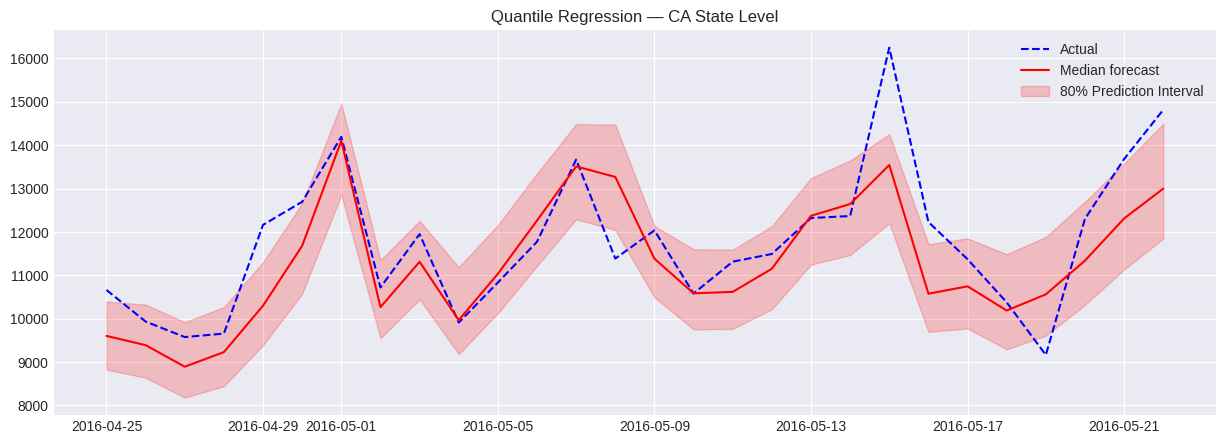

80% interval coverage: 67.9%


In [ ]:
from sklearn.linear_model import QuantileRegressor

# Predict median (more robust than mean)
qr_50 = QuantileRegressor(quantile=0.5, alpha=0).fit(X_train, y_train)

# Predict lower bound (10th percentile)
qr_10 = QuantileRegressor(quantile=0.1, alpha=0).fit(X_train, y_train)

# Predict upper bound (90th percentile)  
qr_90 = QuantileRegressor(quantile=0.9, alpha=0).fit(X_train, y_train)

f_median = qr_50.predict(X_test)
f_lower  = qr_10.predict(X_test)
f_upper  = qr_90.predict(X_test)

plt.figure(figsize=(15, 5))
plt.plot(test['date'], y_test,   'b--',   label='Actual')
plt.plot(test['date'], f_median, 'red',   label='Median forecast')
plt.fill_between(test['date'], f_lower, f_upper,
                 alpha=0.2, color='red', label='80% Prediction Interval')
plt.legend()
plt.title('Quantile Regression — CA State Level')
plt.show()

# Coverage check: what % of actuals fall inside the interval?
coverage = np.mean((y_test >= f_lower) & (y_test <= f_upper))
print(f"80% interval coverage: {coverage:.1%}")
# should be close to 80% — if much lower, intervals are too narrow

## LightGBM:


In [ ]:
import lightgbm as lgb

print(lgb.__version__)

4.6.0


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[28]	valid_0's rmse: 4432.64
Best iteration: 28
LightGBM RMSE: 4432.64

Feature importance:
        feature    importance
0   day_of_week  6.866581e+10
2  week_of_year  8.605689e+09
1  day_of_month  5.892675e+09
3         month  1.966635e+09
4       snap_CA  1.756225e+09


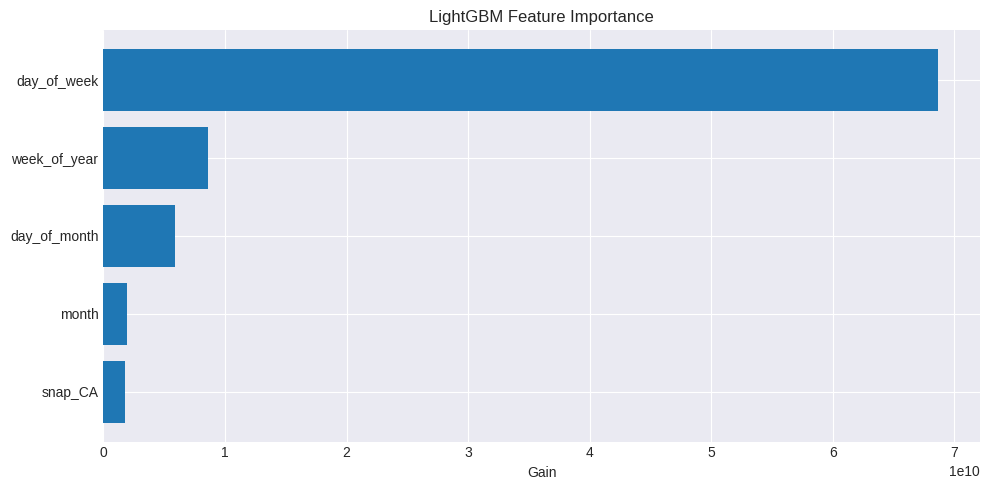


Full comparison:
Linear Reg          : 777
Ridge               : 789
SARIMAX             : 808
Holt-Winters        : 1073
SARIMA              : 1099
S-Naive             : 1305
Rolling             : 3299
ARIMA               : 3445
LightGBM            : 4433
Naive               : 4659


In [ ]:
# we train on the previous same feature cols for comparison
cutoff = ca_df['date'].max() - pd.Timedelta(days=28)
train  = ca_df[ca_df['date'] <= cutoff]
test   = ca_df[ca_df['date'] >  cutoff]

feature_cols = [
    'day_of_week', 'day_of_month', 'week_of_year', 'month',
    
    'snap_CA'
]



X_train = train[feature_cols]
y_train = train['sales']
X_test  = test[feature_cols]
y_test  = test['sales']




lgb_train = lgb.Dataset(X_train,label=y_train)
lgb_val   = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

params = {
    'objective':      'regression',   # minimise RMSE
    'metric':         'rmse',
    'learning_rate':  0.05,           # how much each tree contributes
    'num_leaves':     31,             # max leaves per tree — controls complexity
    'min_data_in_leaf': 20,           # prevents overfitting on small groups
    'feature_fraction': 0.8,          # use 80% of features per tree (randomness)
    'bagging_fraction': 0.8,          # use 80% of data per tree (randomness)
    'bagging_freq':   5,
    'verbose':       -1               # suppress output
}

callbacks = [lgb.early_stopping(50), lgb.log_evaluation(100)]

model_lgb = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,       # max trees to build
    valid_sets=[lgb_val],
    callbacks=callbacks         # stops if val RMSE doesn't improve for 50 rounds
)

print(f"Best iteration: {model_lgb.best_iteration}")

# ── 5. Predict and evaluate ───────────────────────────────────────────────────
f_lgb = model_lgb.predict(X_test)
rmse_lgb = np.sqrt(mean_squared_error(y_test, f_lgb))
print(f"LightGBM RMSE: {rmse_lgb:.2f}")


# ── 6. Feature Importance — most valuable part ────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_lgb.feature_importance(importance_type='gain')
    # 'gain' = total reduction in error this feature caused across all trees
    # more meaningful than 'split' which just counts how often feature was used
}).sort_values('importance', ascending=False)

print("\nFeature importance:")
print(importance_df)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Gain')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── 9. Full model comparison ──────────────────────────────────────────────────
results = {
    'Naive':         4659,
    'S-Naive':       1305,
    'Rolling':       3299,
    'ARIMA':         3445,
    'SARIMA':        1099,
    'SARIMAX':        808,
    'Holt-Winters':  1073,
    'Linear Reg':     777,
    'Ridge':          789,
    'LightGBM':      rmse_lgb,
}
print("\nFull comparison:")
for model, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model:20s}: {rmse:.0f}")

This entire experiment has revealed a hierarchy of what's actually driving your model performance:
1. Sales level (lag_7, lag_28)     → most important, carries everything
2. Weekly pattern (day_of_week)    → second, strong direct signal  
3. SNAP (snap_ca or day_of_month)  → third, but redundant given lags
4. Everything else                 → marginal
And the model ranking now makes complete sense:
Linear Regression (777)  → simple, right-sized for this data, has lags + snap
SARIMAX (808)            → time series structure + snap, well specified
LightGBM with lags (846) → overly complex for aggregated linear data
LightGBM no lags (≈4000) → blind to sales level, cannot forecast

### Important Takeaway Before Item Level
At state level, the dominant signal is the sales level itself — carried by lags. Everything else is secondary. SNAP matters, but it's temporally predictable enough that lags absorb it.
At item level this will break down because:

Item sales are sparse and noisy — lag_7 might be zero or a random spike, not a reliable level signal
SNAP effects are item-specific and non-linear — cat food responds differently than fresh produce
Price changes create discontinuities that lags cannot anticipate



# Item Level

## Section 1: Demand distribution across items

In [ ]:
sales_long

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
item_level = sales_long.groupby(['item_id','date'])['sales'].sum().reset_index()
item_level

,item_id,date,sales
0,FOODS_1_001,2011-01-29,6
1,FOODS_1_001,2011-01-30,6
2,FOODS_1_001,2011-01-31,4
3,FOODS_1_001,2011-02-01,6
4,FOODS_1_001,2011-02-02,7
...,...,...,...
5918104,HOUSEHOLD_2_516,2016-05-18,1
5918105,HOUSEHOLD_2_516,2016-05-19,1
5918106,HOUSEHOLD_2_516,2016-05-20,3
5918107,HOUSEHOLD_2_516,2016-05-21,4


In [ ]:
item_means = item_level.groupby('item_id')['sales'].mean()
print(item_means.describe())
print(f"\nItems with mean sales < 1: {(item_means < 1).sum()}")
print(f"Items with mean sales < 0.5: {(item_means < 0.5).sum()}")

# Zero percentage per item
zero_pct = item_level.groupby('item_id').apply(
    lambda x: (x['sales'] == 0).mean()
)
print(f"\nZero % distribution:")
print(zero_pct.describe())
print(f"Items with >50% zeros: {(zero_pct > 0.5).sum()}")
print(f"Items with >80% zeros: {(zero_pct > 0.8).sum()}")

count    3049.000000
mean       11.308878
std        23.129599
min         0.305513
25%         2.279753
50%         5.040701
75%        11.276662
max       524.428645
Name: sales, dtype: float64

Items with mean sales < 1: 223
Items with mean sales < 0.5: 29

Zero % distribution:
count    3049.000000
mean        0.293475
std         0.230558
min         0.000515
25%         0.083977
50%         0.250902
75%         0.475013
max         0.886656
dtype: float64
Items with >50% zeros: 674
Items with >80% zeros: 13


In [ ]:
zero_pct

item_id
FOODS_1_001        0.096857
FOODS_1_002        0.042761
FOODS_1_003        0.015971
FOODS_1_004        0.282329
FOODS_1_005        0.229778
                     ...   
HOUSEHOLD_2_512    0.015456
HOUSEHOLD_2_513    0.418856
HOUSEHOLD_2_514    0.295209
HOUSEHOLD_2_515    0.692942
HOUSEHOLD_2_516    0.319423
Length: 3049, dtype: float64

                 item_id       date  sales   category
0            FOODS_1_001 2011-01-29      6      FOODS
1            FOODS_1_001 2011-01-30      6      FOODS
2            FOODS_1_001 2011-01-31      4      FOODS
3            FOODS_1_001 2011-02-01      6      FOODS
4            FOODS_1_001 2011-02-02      7      FOODS
...                  ...        ...    ...        ...
5918104  HOUSEHOLD_2_516 2016-05-18      1  HOUSEHOLD
5918105  HOUSEHOLD_2_516 2016-05-19      1  HOUSEHOLD
5918106  HOUSEHOLD_2_516 2016-05-20      3  HOUSEHOLD
5918107  HOUSEHOLD_2_516 2016-05-21      4  HOUSEHOLD
5918108  HOUSEHOLD_2_516 2016-05-22      3  HOUSEHOLD

[5918109 rows x 4 columns]


/tmp/ipykernel_30442/3442740811.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


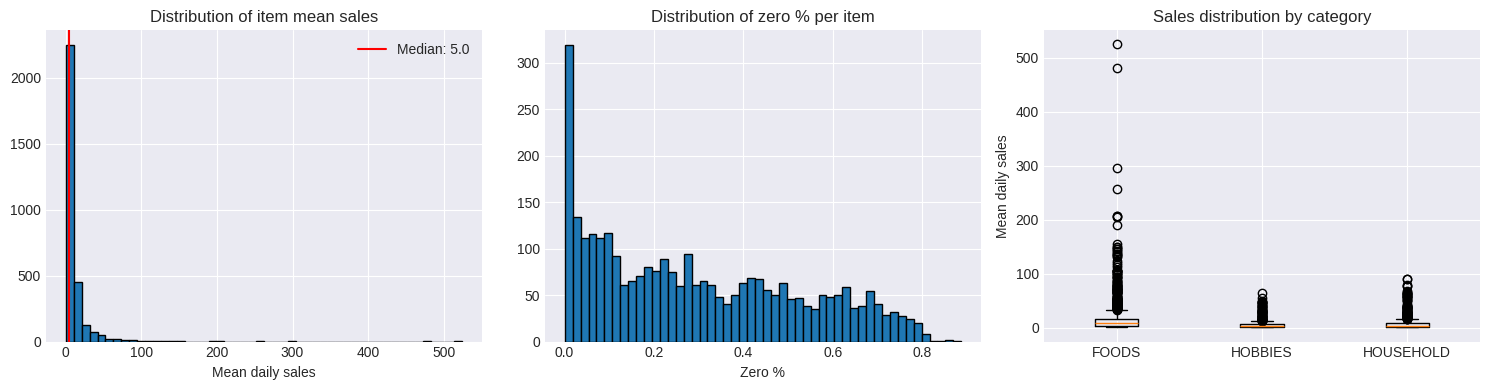

                mean  median        std
category                               
FOODS      16.464272     7.0  37.737008
HOBBIES     5.690576     2.0  11.441061
HOUSEHOLD   7.264981     3.0  14.200236

Zero % by category:
category
FOODS        0.269167
HOBBIES      0.324133
HOUSEHOLD    0.310293
Name: is_zero, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

item_means = item_level.groupby('item_id')['sales'].mean()
zero_pct = item_level.groupby('item_id').apply(
    lambda x: (x['sales'] == 0).mean()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of mean sales — will show the skew
axes[0].hist(item_means, bins=50, edgecolor='black')
axes[0].set_xlabel('Mean daily sales')
axes[0].set_title('Distribution of item mean sales')
axes[0].axvline(item_means.median(), color='red', 
                label=f'Median: {item_means.median():.1f}')
axes[0].legend()

# Distribution of zero %
axes[1].hist(zero_pct, bins=50, edgecolor='black')
axes[1].set_xlabel('Zero %')
axes[1].set_title('Distribution of zero % per item')

# Mean sales by category
cat_sales = item_level.copy()
cat_sales['category'] = cat_sales['item_id'].astype(str).str.split('_').str[0]
print(cat_sales)
cat_means = cat_sales.groupby(['category', 'item_id'])['sales'].mean().reset_index()
axes[2].boxplot(
    [cat_means[cat_means['category']==c]['sales'].values 
     for c in ['FOODS', 'HOBBIES', 'HOUSEHOLD']],
    labels=['FOODS', 'HOBBIES', 'HOUSEHOLD']
)
axes[2].set_ylabel('Mean daily sales')
axes[2].set_title('Sales distribution by category')

plt.tight_layout()
plt.show()

# Print category summary
print(cat_sales.groupby('category')['sales'].agg(['mean','median','std']))
print(f"\nZero % by category:")
cat_sales['is_zero'] = cat_sales['sales'] == 0
print(cat_sales.groupby('category')['is_zero'].mean())

In [ ]:
item_means

item_id
FOODS_1_001         6.390520
FOODS_1_002         3.845956
FOODS_1_003         6.995363
FOODS_1_004        68.135497
FOODS_1_005        12.065430
                     ...    
HOUSEHOLD_2_512     6.031427
HOUSEHOLD_2_513     4.127769
HOUSEHOLD_2_514     1.648120
HOUSEHOLD_2_515     0.594024
HOUSEHOLD_2_516     1.332818
Name: sales, Length: 3049, dtype: float64

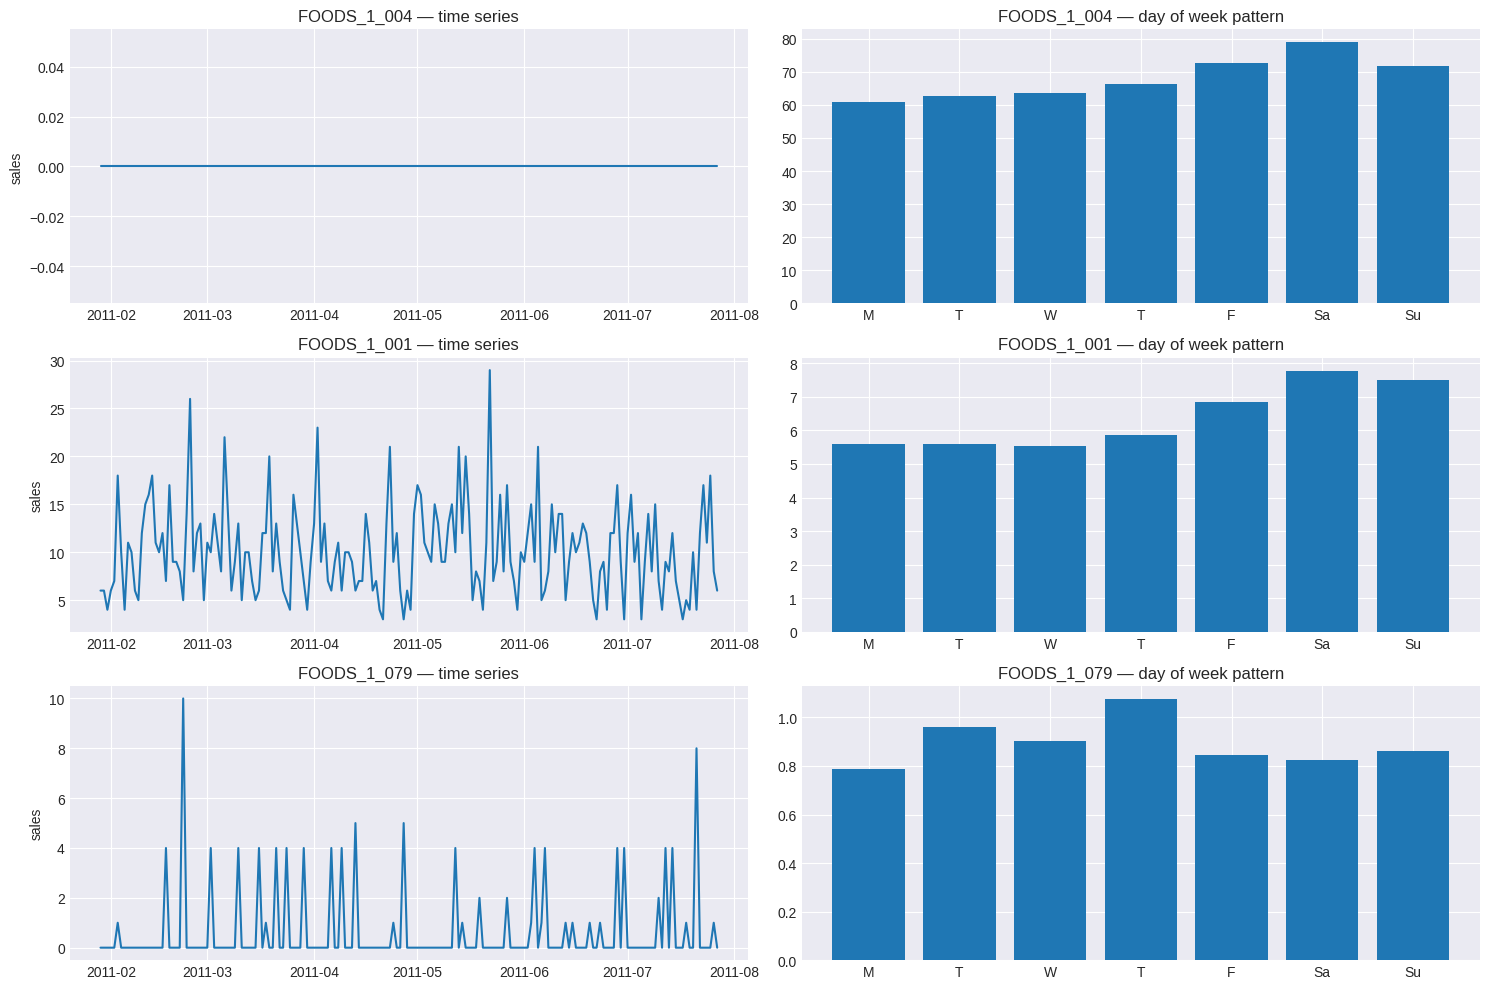

In [ ]:


# High velocity FOODS item
high_vol = item_means[item_means > 50].index[0]

# Medium velocity  
med_vol = item_means[(item_means > 5) & (item_means < 10)].index[0]

# Low velocity / intermittent
low_vol = item_means[item_means < 1].index[0]

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for idx, item in enumerate([high_vol, med_vol, low_vol]):
    item_data = item_level[item_level['item_id'] == item].copy()
    item_data['day_of_week'] = pd.to_datetime(item_data['date']).dt.day_name()
    
    # Time series — first 6 months
    axes[idx, 0].plot(item_data['date'].iloc[:180], 
                      item_data['sales'].iloc[:180])
    axes[idx, 0].set_title(f'{item} — time series')
    axes[idx, 0].set_ylabel('sales')
    
    # Average by day of week
    dow_avg = item_data.groupby('day_of_week')['sales'].mean().reindex(
        ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    )
    axes[idx, 1].bar(range(7), dow_avg.values)
    axes[idx, 1].set_xticks(range(7))
    axes[idx, 1].set_xticklabels(['M','T','W','T','F','Sa','Su'])
    axes[idx, 1].set_title(f'{item} — day of week pattern')

plt.tight_layout()
plt.show()

# Lower Heirarchical level and forecast

# linear Regression models
Although, LR models might perform inferior to tree-based models like XGBoost/ LightGBM, we need to understand how much of a change we get. Unfortunately, with sheer volume of the data, it is not possible computationally to forecast every item. Hence we here look for forecasting each states or sections within each.

In [ ]:
sales_long
# check key uniqueness in the price table
# sell_prices.duplicated(subset=["store_id", "item_id", "wm_yr_wk"]).sum()

# # check dtypes match across both tables
# print(main_df[["store_id","item_id","wm_yr_wk"]].dtypes)
# print(price_df[["store_id","item_id","wm_yr_wk"]].dtypes)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
sales_merged = sales_long.merge(sell_prices,on=['item_id','store_id','wm_yr_wk'],how='left')
sales_merged

/media/ashfaque/datas/ML-projects/retail-forecast-system/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.980469
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.480469
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,3.980469
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,1.280273


In [ ]:
mask_ca = sales_merged['state_id']=='CA'
sales_long_ca = sales_merged[mask_ca]

#for category 
cat = 'FOODS'
store = 'CA_1'

sales_long_ca_foods = sales_long_ca[sales_long_ca['cat_id']==cat]
sales_long_ca_foods = sales_long_ca_foods[sales_long_ca_foods['store_id']==store]

sales_long_ca_foods.reset_index()

/media/ashfaque/datas/ML-projects/retail-forecast-system/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,index,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.000000
1,1613,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.878906
2,1614,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.880859
3,1615,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,1616,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.939453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2789212,59153644,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1941,2,2016-05-22,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.980469
2789213,59153645,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1941,0,2016-05-22,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.480469
2789214,59153646,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,3.980469
2789215,59153647,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,1.280273


In [ ]:

sales_long_ca_foods['day_of_week']   = sales_long_ca_foods['date'].dt.dayofweek      # 0=Monday, 6=Sunday
sales_long_ca_foods['day_of_month']  = sales_long_ca_foods['date'].dt.day
sales_long_ca_foods['week_of_year']  = sales_long_ca_foods['date'].dt.isocalendar().week.astype(int)
sales_long_ca_foods['month']         = sales_long_ca_foods['date'].dt.month

sales_long_ca_foods.reset_index()

/media/ashfaque/datas/ML-projects/retail-forecast-system/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,index,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,...,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day_of_week,day_of_month,week_of_year
0,1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,...,NaN,NaN,NaN,0,0,0,2.000000,5,29,4
1,1613,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,...,NaN,NaN,NaN,0,0,0,7.878906,5,29,4
2,1614,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,...,NaN,NaN,NaN,0,0,0,2.880859,5,29,4
3,1615,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,...,NaN,NaN,NaN,0,0,0,NaN,5,29,4
4,1616,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,...,NaN,NaN,NaN,0,0,0,2.939453,5,29,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2789212,59153644,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1941,2,2016-05-22,...,NaN,NaN,NaN,0,0,0,2.980469,6,22,20
2789213,59153645,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1941,0,2016-05-22,...,NaN,NaN,NaN,0,0,0,2.480469,6,22,20
2789214,59153646,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,...,NaN,NaN,NaN,0,0,0,3.980469,6,22,20
2789215,59153647,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,...,NaN,NaN,NaN,0,0,0,1.280273,6,22,20


In [ ]:
sales_long_ca_foods['sell_price'] = sales_long_ca_foods.sort_values(['item_id','date']).groupby('item_id')['sell_price'].bfill()

In [ ]:
revenue_df = ( sales_long_ca_foods.assign(revenue = lambda x: x['sales'] * x['sell_price']).groupby(['item_id', 'date'])['revenue'].sum().reset_index())
revenue_df_item = revenue_df.groupby('item_id')['revenue'].sum().reset_index()
revenue_df_item

,item_id,revenue
0,FOODS_1_001,3280.222656
1,FOODS_1_002,8252.007812
2,FOODS_1_003,4772.951172
3,FOODS_1_004,29183.539062
4,FOODS_1_005,7540.308594
...,...,...
1432,FOODS_3_823,3108.820312
1433,FOODS_3_824,3635.064453
1434,FOODS_3_825,7610.371094
1435,FOODS_3_826,2291.689453


In [ ]:
# Scale: per-item naive forecast error on training data
def scale(train_df):
    train_sorted = train_df.sort_values(['item_id', 'date'])
    diffs = train_sorted.groupby('item_id')['sales'].diff()
    return train_sorted.assign(diff=diffs).groupby('item_id').apply(
        lambda x: np.sqrt(np.mean(x['diff'].dropna()**2))
    )  # Series indexed by item_id, shape (n_items,)

# Forecast error: per-item RMSE over horizon
def forecast_error(test_df, pred_df):
    # pred_df: same structure as test_df but with 'sales' = predicted values
    merged = test_df[['item_id','date','sales']].merge(
        pred_df[['item_id','date','sales_pred']], on=['item_id','date']
    )

    # assert test_df.shape[0] == pred_df.shape[0]


    return merged.groupby('item_id').apply(lambda x: np.sqrt(np.mean((x['sales'] - x['sales_pred'])**2)))
    # Series indexed by item_id
    # return np.sqrt(np.mean(test_df['sales']-pred_df)**2)

# Weights: last 28 days of training revenue share
def weights(train_df):
    last28 = train_df['date'] >= train_df['date'].max() - pd.Timedelta(days=27)
    rev = (train_df[last28]
           .assign(revenue=lambda x: x['sales'] * x['sell_price'])
           .groupby('item_id')['revenue'].sum())
    return rev / rev.sum()

# Final WRMSSE
def wrmsse(train_df, test_df, pred_df):
    w = weights(train_df)
    s = scale(train_df)
    fe = forecast_error(test_df, pred_df)
    # align all three on item_id
    items = w.index
    return float(np.sum(w.loc[items] * fe.loc[items] / s.loc[items]))

In [ ]:
# to drop 
cols_to_drop = ['id','state_id','store_id','d_x','snap_TX','snap_WI','cat_id']
sales_foods_ca = sales_long_ca_foods.drop(columns=cols_to_drop)
sales_foods_ca

KeyError: "['d_x'] not found in axis"

## One-Hot-Encode cateogorical variables
'dept_id', 'store_id' only 7 unique items combined, easy to one hot encode. However 'item_id' have ~1400 items, might create dense matrix which will leads to RAM running out. So we go for sparse encoding.

* Events are Nans. convert to 'none'

In [ ]:
cat_cols_small = ['dept_id','event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
num_cols = ['day_of_month', 'day_of_week', 'week_of_year', 'month', 'year', 'snap_CA','sell_price']

# fill event NaNs first
for col in ['event_name_1','event_type_1','event_name_2','event_type_2']:
   sales_long_ca_foods[col] =sales_long_ca_foods[col].astype('string').fillna('none').astype('category')



cutoff =sales_long_ca_foods['date'].max() - pd.Timedelta(days=28)
train =sales_long_ca_foods[sales_long_ca_foods['date'] <= cutoff]
test  =sales_long_ca_foods[sales_long_ca_foods['date'] > cutoff]

# small categoricals: dense one-hot is fine
train_small = pd.get_dummies(train[cat_cols_small])
test_small  = pd.get_dummies(test[cat_cols_small]).reindex(columns=train_small.columns, fill_value=0)

# # high-cardinality item_id: sparse one-hot
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
item_train = ohe.fit_transform(train[['item_id']])
item_test  = ohe.transform(test[['item_id']])

X_train = hstack([
    item_train, 
    csr_matrix(train_small.values.astype('float32')), 
    csr_matrix(train[num_cols].values.astype('float32'))
])
# X_train = hstack([item_train, csr_matrix(train_small.values), csr_matrix(train[num_cols].values)])

X_test  = hstack([item_test,  csr_matrix(test_small.values.astype('float32')),  csr_matrix(test[num_cols].values.astype('float32'))])

# print(X_train.shape,X_test.shape)
y_train, y_test = train['sales'], test['sales']

lr = LinearRegression()
lr.fit(X_train, y_train)
print('predicting the values...')
preds = lr.predict(X_test)

# # rmse = np.sqrt(mean_squared_error(y_test, preds))
# metric = wrmsse(train,test,preds)
# print(f"RMSE: {metric:.3f}")

predicting the values...


In [ ]:
pred_df = test[['item_id', 'date']].copy()
pred_df['sales_pred'] = preds 
pred_df

,item_id,date,sales_pred
58328982,FOODS_1_001,2016-04-25,0.456704
58328983,FOODS_1_002,2016-04-25,-0.311424
58328984,FOODS_1_003,2016-04-25,0.324059
58328985,FOODS_1_004,2016-04-25,7.877465
58328986,FOODS_1_005,2016-04-25,0.701185
...,...,...,...
59153644,FOODS_3_823,2016-05-22,0.985558
59153645,FOODS_3_824,2016-05-22,1.514123
59153646,FOODS_3_825,2016-05-22,1.747905
59153647,FOODS_3_826,2016-05-22,1.574864


In [ ]:
metric = wrmsse(train, test, pred_df)
print('linearreg WRMSSE: ',metric)

linearreg WRMSSE:  1.0469712431946043


In [ ]:
feature_cols = ['item_id', 'dept_id', 'store_id'] + num_cols + ['event_name_1','event_type_1','event_name_2','event_type_2']

train_lgb = train[feature_cols].copy()
test_lgb  = test[feature_cols].copy()

for col in ['item_id', 'dept_id', 'store_id', 'event_name_1','event_type_1','event_name_2','event_type_2']:
    train_lgb[col] = train_lgb[col].astype('category')
    test_lgb[col]  = test_lgb[col].astype('category')

lgb_model = lgb.LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, verbose=-1)
lgb_model.fit(train_lgb, y_train)
lgb_preds = lgb_model.predict(test_lgb)

# reconstruct pred_df using test which still has item_id and date
pred_df = test[['item_id', 'date']].copy()
pred_df['sales_pred'] = lgb_preds

metric = wrmsse(train, test, pred_df)
print(f"LightGBM WRMSSE: {metric:.4f}")

LightGBM WRMSSE: 0.9680


In [ ]:
# from sklearn.linear_model import LinearRegression
# from scipy.sparse import hstack, csr_matrix
# from sklearn.preprocessing import OneHotEncoder
# import lightgbm as lgb

# cat_cols = ['event_name_1','event_type_1','event_name_2','event_type_2']
# num_cols = ['day_of_month', 'day_of_week', 'week_of_year', 'month', 'year', 'snap_CA', 'sell_price']
# lgb_cat_cols = ['item_id', 'dept_id', 'store_id'] + cat_cols

# years = [2012, 2013, 2014, 2015, 2016]
# results = []

# for year in years:
#     cutoff = pd.Timestamp(f'{year}-12-31') - pd.Timedelta(days=28)
#     test_end = pd.Timestamp(f'{year}-12-31')
    
#     train = sales_long_ca_foods[sales_long_ca_foods['date'] <= cutoff]
#     test  = sales_long_ca_foods[(sales_long_ca_foods['date'] > cutoff) & 
#                                  (sales_long_ca_foods['date'] <= test_end)]
    
#     y_train = train['sales']
#     y_test  = test['sales']

#     # --- LightGBM ---
#     train_lgb = train[lgb_cat_cols + num_cols].copy()
#     test_lgb  = test[lgb_cat_cols + num_cols].copy()
#     for col in lgb_cat_cols:
#         train_lgb[col] = train_lgb[col].astype('category')
#         test_lgb[col]  = test_lgb[col].astype('category')
    
#     lgb_model = lgb.LGBMRegressor(n_estimators=200, max_depth=8, 
#                                    learning_rate=0.05, verbose=-1)
#     lgb_model.fit(train_lgb, y_train)
#     lgb_preds = lgb_model.predict(test_lgb)
#     pred_df = test[['item_id','date']].copy()
#     pred_df['sales_pred'] = lgb_preds
#     lgb_score = wrmsse(train, test, pred_df)

#     # --- Linear Regression ---
#     for col in cat_cols:
#         train[col] = train[col].astype('string').fillna('none').astype('category')
#         test[col]  = test[col].astype('string').fillna('none').astype('category')

#     train_small = pd.get_dummies(train[cat_cols])
#     test_small  = pd.get_dummies(test[cat_cols]).reindex(columns=train_small.columns, fill_value=0)

#     ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
#     item_train = ohe.fit_transform(train[['item_id']])
#     item_test  = ohe.transform(test[['item_id']])

#     X_train = hstack([item_train, 
#                       csr_matrix(train_small.values.astype('float32')),
#                       csr_matrix(train[num_cols].values.astype('float32'))])
#     X_test  = hstack([item_test,
#                       csr_matrix(test_small.values.astype('float32')),
#                       csr_matrix(test[num_cols].values.astype('float32'))])

#     lr = LinearRegression()
#     lr.fit(X_train, y_train)
#     lr_preds = lr.predict(X_test)
#     pred_df_lr = test[['item_id','date']].copy()
#     pred_df_lr['sales_pred'] = lr_preds
#     lr_score = wrmsse(train, test, pred_df_lr)

#     results.append({'year': year, 'lgb_wrmsse': lgb_score, 'lr_wrmsse': lr_score})
#     print(f"Year {year} | LGB: {lgb_score:.4f} | LR: {lr_score:.4f}")

# results_df = pd.DataFrame(results)
# print("\nMean WRMSSE:")
# print(results_df[['lgb_wrmsse','lr_wrmsse']].mean())

In [ ]:
sales_long_ca_foods = sales_long_ca_foods.sort_values(['item_id', 'date'])

for lag in [7, 14, 28]:
    sales_long_ca_foods[f'lag_{lag}'] = (
        sales_long_ca_foods.groupby('item_id')['sales']
        .shift(lag)
    )

for window in [7, 28]:
    sales_long_ca_foods[f'rolling_mean_{window}'] = (
        sales_long_ca_foods
        .groupby('item_id')['sales']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

In [ ]:
num_cols += ['lag_7','lag_14','lag_28','rolling_mean_28','rolling_mean_7']


In [ ]:
feature_cols = ['item_id', 'dept_id', 'store_id'] + num_cols + ['event_name_1','event_type_1','event_name_2','event_type_2']

cutoff =sales_long_ca_foods['date'].max() - pd.Timedelta(days=28)
train =sales_long_ca_foods[sales_long_ca_foods['date'] <= cutoff]
test  =sales_long_ca_foods[sales_long_ca_foods['date'] > cutoff]

train_lgb = train[feature_cols].copy()
test_lgb  = test[feature_cols].copy()

y_train, y_test = train['sales'], test['sales']

for col in ['item_id', 'dept_id', 'store_id', 'event_name_1','event_type_1','event_name_2','event_type_2']:
    train_lgb[col] = train_lgb[col].astype('category')
    test_lgb[col]  = test_lgb[col].astype('category')

lgb_model = lgb.LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, verbose=-1)
lgb_model.fit(train_lgb, y_train)
lgb_preds = lgb_model.predict(test_lgb)

# reconstruct pred_df using test which still has item_id and date
pred_df = test[['item_id', 'date']].copy()
pred_df['sales_pred'] = lgb_preds

metric = wrmsse(train, test, pred_df)
print(f"LightGBM WRMSSE: {metric:.4f}")

LightGBM WRMSSE: 0.8455


In [ ]:
test_lgb['date'] = pd.to_datetime(test_lgb[['year','month','day_of_month']].rename(columns={'day_of_month': 'day'})) 

test_lgb

/media/ashfaque/datas/ML-projects/retail-forecast-system/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,item_id,dept_id,store_id,day_of_month,day_of_week,week_of_year,month,year,snap_CA,sell_price,lag_7,lag_14,lag_28,rolling_mean_28,rolling_mean_7,event_name_1,event_type_1,event_name_2,event_type_2,date
58328982,FOODS_1_001,FOODS_1,CA_1,25,0,17,4,2016,0,2.240234,4.0,2.0,2.0,1.178571,1.142857,none,none,none,none,2016-04-25
58359472,FOODS_1_001,FOODS_1,CA_1,26,1,17,4,2016,0,2.240234,1.0,0.0,1.0,1.178571,0.857143,none,none,none,none,2016-04-26
58389962,FOODS_1_001,FOODS_1,CA_1,27,2,17,4,2016,0,2.240234,1.0,1.0,1.0,1.142857,0.714286,none,none,none,none,2016-04-27
58420452,FOODS_1_001,FOODS_1,CA_1,28,3,17,4,2016,0,2.240234,0.0,1.0,0.0,1.107143,0.571429,none,none,none,none,2016-04-28
58450942,FOODS_1_001,FOODS_1,CA_1,29,4,17,4,2016,0,2.240234,1.0,0.0,4.0,1.107143,0.571429,none,none,none,none,2016-04-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59031688,FOODS_3_827,FOODS_3,CA_1,18,2,20,5,2016,0,1.000000,4.0,12.0,3.0,5.000000,4.571429,none,none,none,none,2016-05-18
59062178,FOODS_3_827,FOODS_3,CA_1,19,3,20,5,2016,0,1.000000,6.0,7.0,3.0,5.071429,4.714286,none,none,none,none,2016-05-19
59092668,FOODS_3_827,FOODS_3,CA_1,20,4,20,5,2016,0,1.000000,10.0,8.0,5.0,5.214286,4.857143,none,none,none,none,2016-05-20
59123158,FOODS_3_827,FOODS_3,CA_1,21,5,20,5,2016,0,1.000000,3.0,5.0,3.0,5.107143,3.714286,none,none,none,none,2016-05-21


## Recursive Method:
* lag 7, 14, 28, rolling mean 7, 28 
We calculate the above features recursively for the predicting horizon and include it as history for predicting next step.

In [ ]:
def predict_next_day(model,next_day_features):
    next_day = model.predict(next_day_features)
    return next_day

def update_history(history,prediction):
    history.append(prediction)
    return history

def get_lag_rolling_features(train_df):

    for lag in [7, 14, 28]:
        train_df[f'lag_{lag}'] = (
            train_df.groupby('item_id')['sales']
            .shift(lag)
        )

    for window in [7, 28]:
        train_df[f'rolling_mean_{window}'] = (
            train_df
            .groupby('item_id')['sales']
            .transform(lambda x: x.shift(1).rolling(window).mean())
        )

    return train_df

recalc_feature_cols = ['lag_7','lag_14','lag_28','rolling_mean_7','rolling_mean_28']

In [ ]:
def predict_next_day(model, next_day_features):
    preds = model.predict(next_day_features)
    return np.maximum(preds, 0)  # sales can't be negative

def update_history(history, day, item_ids, predictions):
    new_rows = pd.DataFrame({'item_id': item_ids, 'date': day, 'sales': predictions})
    return pd.concat([history, new_rows], ignore_index=True)

def get_lag_rolling_features(df):
    df = df.sort_values(['item_id', 'date'])
    for lag in [7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby('item_id')['sales'].shift(lag)
    for window in [7, 28]:
        df[f'rolling_mean_{window}'] = (
            df.groupby('item_id')['sales'].transform(lambda x: x.shift(1).rolling(window).mean())
        )
    return df
recalc_feature_cols = ['lag_7','lag_14','lag_28','rolling_mean_7','rolling_mean_28']

In [ ]:
history = train[['item_id', 'date', 'sales']].copy()
forecast_horizon = sorted(test_lgb['date'].unique())

cat_cols = ['item_id', 'dept_id', 'store_id', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
known_num_cols = ['day_of_month', 'day_of_week', 'week_of_year', 'month', 'year', 'snap_CA', 'sell_price']

all_preds = []

for day in forecast_horizon:
    day_static = test[test['date'] == day][cat_cols + known_num_cols].copy()

    # placeholder rows so lag/rolling has "today" to shift into
    placeholder = day_static[['item_id']].copy()
    placeholder['date'] = day
    placeholder['sales'] = np.nan
    history_ext = get_lag_rolling_features(pd.concat([history, placeholder], ignore_index=True))

    today_feats = history_ext[history_ext['date'] == day][['item_id'] + recalc_feature_cols]
    row = day_static.merge(today_feats, on='item_id')

    for col in cat_cols:
        row[col] = pd.Categorical(row[col], categories=train_lgb[col].cat.categories)
    row = row[train_lgb.columns]

    preds = predict_next_day(lgb_model, row)
    all_preds.append(pd.DataFrame({'item_id': row['item_id'].values, 'date': day, 'sales_pred': preds}))

    history = update_history(history, day, row['item_id'].values, preds)

pred_df_recursive = pd.concat(all_preds, ignore_index=True)

In [ ]:
metric = wrmsse(train,test,pred_df_recursive)
print('recursive WRMSSE: ', metric)

recursive WRMSSE:  0.8849807655938736


## Final Model: lightGBM on entire dataset

In [12]:
import warnings
# Silence the pandas formatting string cast warnings globally within this notebook
warnings.filterwarnings(
    action='ignore', 
    category=RuntimeWarning, 
    message='overflow encountered in cast'
)

In [13]:
sales_merged = sales_long.merge(sell_prices,on=['item_id','store_id','wm_yr_wk'],how='left')
sales_merged


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.980469
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.480469
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,3.980469
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,1.280273


filling the nan values in sell prices using backfill

In [14]:
sales_merged['sell_price'] = sales_merged.sort_values(['id','date']).groupby('id')['sell_price'].bfill()
sales_merged['sell_price'].isna().sum()


np.int64(0)

In [15]:
sales_merged

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,9.578125
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,3.970703
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.970703
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,4.339844
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.980469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.980469
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,2.480469
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,3.980469
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,NaN,NaN,NaN,NaN,0,0,0,1.280273


In [16]:
sales_merged['day_of_week']   = sales_merged['date'].dt.dayofweek      # 0=Monday, 6=Sunday
sales_merged['day_of_month']  = sales_merged['date'].dt.day
sales_merged['week_of_year']  = sales_merged['date'].dt.isocalendar().week.astype(int)
sales_merged['month']         = sales_merged['date'].dt.month

creating lag and rolling features for lightgbm model


In [17]:
sales_merged['revenue'] = sales_merged['sales']*sales_merged['sell_price']
sales_merged['id'] = sales_merged['id'].astype('category')
sales_merged

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day_of_week,day_of_month,week_of_year,revenue
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,9.578125,5,29,4,0.000000
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,3.970703,5,29,4,0.000000
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,2.970703,5,29,4,0.000000
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,4.339844,5,29,4,0.000000
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,2.980469,5,29,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,NaN,NaN,0,0,0,2.980469,6,22,20,2.980469
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,NaN,NaN,0,0,0,2.480469,6,22,20,0.000000
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,NaN,NaN,0,0,0,3.980469,6,22,20,7.960938
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,NaN,NaN,0,0,0,1.280273,6,22,20,0.000000


In [ ]:
# print(sales_merged.shape)
# print(sales_merged.memory_usage(deep=True).sum() / 1e9, "GB")
# print(sales_merged.dtypes)

# we cannot use the entire dataset as it is very heavy, so it would be better to build models seperately for each stores

In [18]:
sales_ca1 = sales_merged[sales_merged['store_id']=='CA_1']
sales_ca1

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day_of_week,day_of_month,week_of_year,revenue
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,9.578125,5,29,4,0.000000
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,3.970703,5,29,4,0.000000
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,2.970703,5,29,4,0.000000
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,4.339844,5,29,4,0.000000
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,2.980469,5,29,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59153644,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1941,2,2016-05-22,11617,...,NaN,NaN,0,0,0,2.980469,6,22,20,5.960938
59153645,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1941,0,2016-05-22,11617,...,NaN,NaN,0,0,0,2.480469,6,22,20,0.000000
59153646,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,NaN,NaN,0,0,0,3.980469,6,22,20,3.980469
59153647,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,NaN,NaN,0,0,0,1.280273,6,22,20,1.280273


In [19]:
def create_lag_rolling_features(df, main_id='id'): 

    for lag in [7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby(main_id)['sales'].shift(lag)

    # compute the shift(1) ONCE, reuse for both rolling windows
    sales_shifted = df.groupby(main_id, observed=True)['sales'].shift(1)

    for window in [7, 28]:
        df[f'rolling_mean_{window}'] = (
            sales_shifted.groupby(sales_merged[main_id])
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )
        
    return df

In [19]:
sales_ca1

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day_of_week,day_of_month,week_of_year,revenue
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,9.578125,5,29,4,0.000000
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,3.970703,5,29,4,0.000000
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,2.970703,5,29,4,0.000000
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,4.339844,5,29,4,0.000000
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,0,0,0,2.980469,5,29,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59153644,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1941,2,2016-05-22,11617,...,NaN,NaN,0,0,0,2.980469,6,22,20,5.960938
59153645,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1941,0,2016-05-22,11617,...,NaN,NaN,0,0,0,2.480469,6,22,20,0.000000
59153646,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,NaN,NaN,0,0,0,3.980469,6,22,20,3.980469
59153647,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,NaN,NaN,0,0,0,1.280273,6,22,20,1.280273


In [20]:
sales_ca1_lag = create_lag_rolling_features(sales_ca1)
sales_ca1_lag

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,sell_price,day_of_week,day_of_month,week_of_year,revenue,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,9.578125,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,3.970703,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2.970703,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,4.339844,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2.980469,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59153644,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1941,2,2016-05-22,11617,...,2.980469,6,22,20,5.960938,3.0,1.0,1.0,2.428571,1.500000
59153645,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1941,0,2016-05-22,11617,...,2.480469,6,22,20,0.000000,0.0,0.0,0.0,0.857143,1.035714
59153646,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,3.980469,6,22,20,3.980469,0.0,3.0,2.0,1.000000,1.178571
59153647,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,1.280273,6,22,20,1.280273,2.0,0.0,0.0,1.714286,0.928571


In [21]:
# Scale: per-item naive forecast error on training data
def scale(train_df):
    train_sorted = train_df.sort_values(['item_id', 'date'])
    diffs = train_sorted.groupby('item_id')['sales'].diff()
    return train_sorted.assign(diff=diffs).groupby('item_id').apply(
        lambda x: np.sqrt(np.mean(x['diff'].dropna()**2))
    )  # Series indexed by item_id, shape (n_items,)

# Forecast error: per-item RMSE over horizon
def forecast_error(test_df, pred_df):
    # pred_df: same structure as test_df but with 'sales' = predicted values
    merged = test_df[['item_id','date','sales']].merge(
        pred_df[['item_id','date','sales_pred']], on=['item_id','date']
    )

    # assert test_df.shape[0] == pred_df.shape[0]


    return merged.groupby('item_id').apply(lambda x: np.sqrt(np.mean((x['sales'] - x['sales_pred'])**2)))
    # Series indexed by item_id
    # return np.sqrt(np.mean(test_df['sales']-pred_df)**2)

# Weights: last 28 days of training revenue share
def weights(train_df):
    last28 = train_df['date'] >= train_df['date'].max() - pd.Timedelta(days=27)
    rev = (train_df[last28]
           .assign(revenue=lambda x: x['sales'] * x['sell_price'])
           .groupby('item_id')['revenue'].sum())
    return rev / rev.sum()

# Final WRMSSE
def wrmsse(train_df, test_df, pred_df):
    w = weights(train_df)
    s = scale(train_df)
    fe = forecast_error(test_df, pred_df)
    # align all three on item_id
    items = w.index
    return float(np.sum(w.loc[items] * fe.loc[items] / s.loc[items]))

In [26]:
import lightgbm as lgb

cutoff =sales_ca1_lag['date'].max() - pd.Timedelta(days=28)
train_ca =sales_ca1_lag[sales_ca1_lag['date'] <= cutoff]
test_ca  =sales_ca1_lag[sales_ca1_lag['date'] > cutoff]


feature_cols = ['item_id', 'dept_id','cat_id','lag_7','lag_28','rolling_mean_7','rolling_mean_28','lag_14','event_name_1','event_type_1','event_name_2','event_type_2','day_of_week','day_of_month','week_of_year','sell_price','snap_CA','month','year']



train_lgb = train_ca[feature_cols].copy()
test_lgb  = test_ca[feature_cols].copy()

y_train, y_test = train_ca['sales'], test_ca['sales']

for col in ['item_id', 'dept_id', 'event_name_1','event_type_1','event_name_2','event_type_2']:
    train_lgb[col] = train_lgb[col].astype('category')
    test_lgb[col]  = test_lgb[col].astype('category')
    
print("fitting the model")
lgb_model = lgb.LGBMRegressor(objective='tweedie',n_estimators=200, max_depth=8, learning_rate=0.05, verbose=-1)
lgb_model.fit(train_lgb, y_train)
lgb_preds = lgb_model.predict(test_lgb)

# reconstruct pred_df using test which still has item_id and date
pred_df = test_ca[['item_id', 'date']].copy()
pred_df['sales_pred'] = lgb_preds


fitting the model


In [36]:
lgb_quant_10 = lgb.LGBMRegressor(objective='quantile',alpha=0.1, n_estimators=200,max_depth=8,learning_rate=0.05,verbose=-1)
lgb_quant_10.fit(train_lgb,y_train)

lgb_quant_90 = lgb.LGBMRegressor(objective='quantile',alpha=0.9, n_estimators=200,max_depth=8,learning_rate=0.05,verbose=-1)
lgb_quant_90.fit(train_lgb,y_train) 


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'quantile'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [33]:
metric = wrmsse(train_ca, test_ca, pred_df)
print(f"LightGBM WRMSSE: {metric:.4f}")

LightGBM WRMSSE: 0.8861


In [27]:
import joblib
# training full data
X_full = sales_ca1_lag[feature_cols].copy()
y_full = sales_ca1_lag['sales']

# lgb_model_deploy = lgb.LGBMRegressor(objective='tweedie', n_estimators=200, max_depth=8, learning_rate=0.05, verbose=-1)
# lgb_model_deploy.fit(X_full, y_full)



# joblib.dump(lgb_model_deploy, '../models/lgb_model_ca1_deploy.pkl')


In [28]:
lgb_quant_10_deploy = lgb.LGBMRegressor(objective='quantile', alpha=0.1, n_estimators=200, max_depth=8, learning_rate=0.05, verbose=-1)
lgb_quant_10_deploy.fit(X_full, y_full)
joblib.dump(lgb_quant_10_deploy, '../models/lgb_q10_ca1_deploy.pkl')


['../models/lgb_q10_ca1_deploy.pkl']

In [29]:

lgb_quant_90_deploy = lgb.LGBMRegressor(objective='quantile', alpha=0.9, n_estimators=200, max_depth=8, learning_rate=0.05, verbose=-1)
lgb_quant_90_deploy.fit(X_full, y_full)
joblib.dump(lgb_quant_90_deploy, '../models/lgb_q90_ca1_deploy.pkl')

['../models/lgb_q90_ca1_deploy.pkl']

In [34]:
sales_ca1_lag

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,sell_price,day_of_week,day_of_month,week_of_year,revenue,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,9.578125,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,3.970703,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2.970703,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,4.339844,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2.980469,5,29,4,0.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59153644,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1941,2,2016-05-22,11617,...,2.980469,6,22,20,5.960938,3.0,1.0,1.0,2.428571,1.500000
59153645,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1941,0,2016-05-22,11617,...,2.480469,6,22,20,0.000000,0.0,0.0,0.0,0.857143,1.035714
59153646,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,3.980469,6,22,20,3.980469,0.0,3.0,2.0,1.000000,1.178571
59153647,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1941,1,2016-05-22,11617,...,1.280273,6,22,20,1.280273,2.0,0.0,0.0,1.714286,0.928571


In [33]:
calender

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
import fastparquet

cat_categories = {
    col: train_lgb[col].cat.categories.tolist()
    for col in ['item_id', 'dept_id', 'cat_id', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
}
joblib.dump(cat_categories, '../models/cat_categories_ca1.pkl')
joblib.dump(feature_cols, '../models/feature_cols_ca1.pkl')

# save recent history — needed to seed lag/rolling features at inference time
recent_history = train_ca[train_ca['date'] >= train_ca['date'].max() - pd.Timedelta(days=35)][
    ['id', 'item_id', 'dept_id', 'cat_id', 'date', 'sales','day_of_week','day_of_month','week_of_year','snap_CA','sell_prices']
].copy()
recent_history.to_parquet('../models/recent_history_ca1.parquet')

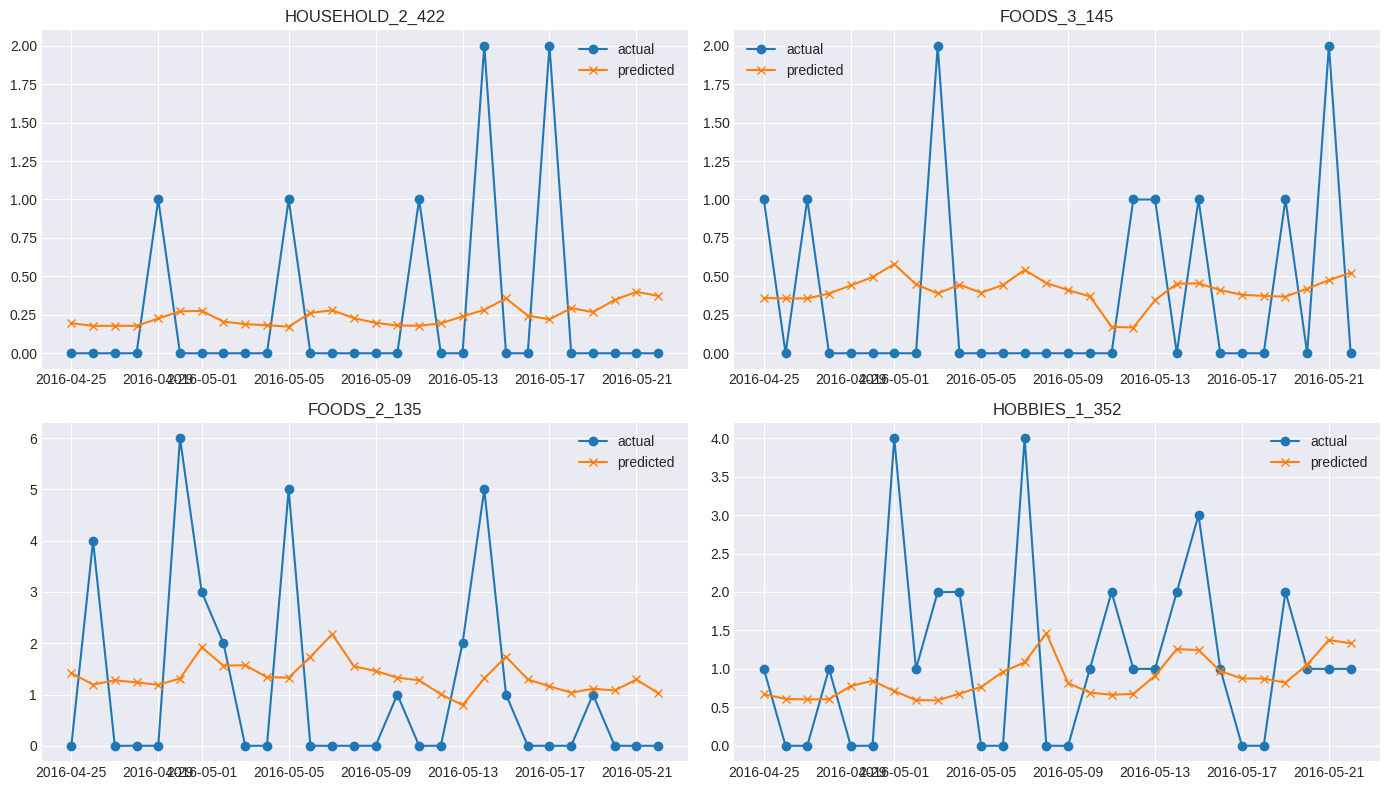

In [34]:
import matplotlib.pyplot as plt

sample_items = pred_df['item_id'].drop_duplicates().sample(4, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, item in zip(axes.flat, sample_items):
    actual = test_ca[test_ca['item_id'] == item][['date', 'sales']]
    pred = pred_df[pred_df['item_id'] == item][['date', 'sales_pred']]
    ax.plot(actual['date'], actual['sales'], label='actual', marker='o')
    ax.plot(pred['date'], pred['sales_pred'], label='predicted', marker='x')
    ax.set_title(item)
    ax.legend()
plt.tight_layout()
plt.show()

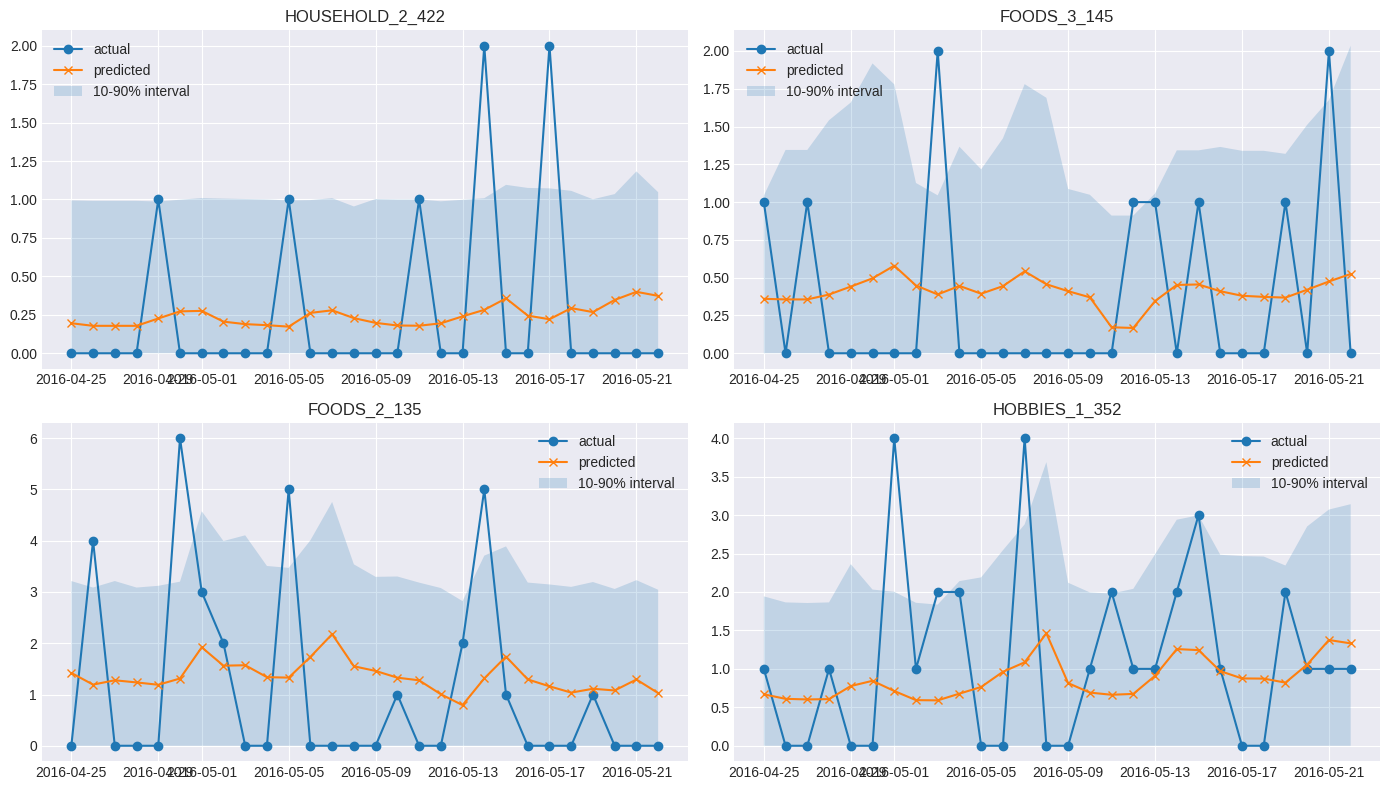

In [37]:
q10_preds = lgb_quant_10.predict(test_lgb)
q90_preds = lgb_quant_90.predict(test_lgb)

pred_df['q10'] = np.maximum(q10_preds, 0)
pred_df['q90'] = np.maximum(q90_preds, 0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, item in zip(axes.flat, sample_items):
    actual = test_ca[test_ca['item_id'] == item][['date', 'sales']]
    pred = pred_df[pred_df['item_id'] == item][['date', 'sales_pred', 'q10', 'q90']]

    ax.plot(actual['date'], actual['sales'], label='actual', marker='o')
    ax.plot(pred['date'], pred['sales_pred'], label='predicted', marker='x')
    ax.fill_between(pred['date'], pred['q10'], pred['q90'], alpha=0.2, label='10-90% interval')
    ax.set_title(item)
    ax.legend()
plt.tight_layout()
plt.show()

In [38]:
within_band = (pred_df['sales_pred'].notna()) & \
              (test_ca.merge(pred_df, on=['item_id','date'])['sales'].between(
                  pred_df['q10'], pred_df['q90']))
print(within_band.mean())  # should land roughly around 0.75-0.85 for an 80% interval

ValueError: Can only compare identically-labeled Series objects